# Epsilon_study_2 — analysis

Validation gate first (eps2val rows: $\sigma_{\rm res}=0,\sigma_{\rm scatt}=10^{-4}$); then sensitivity grid.

All inputs come from `results/eps2_events.csv` and `results/eps2_summary.csv` produced by `aggregate.sh`.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
HERE = Path('.').resolve()
ev = pd.read_csv(HERE/'results'/'eps2_events.csv')
su = pd.read_csv(HERE/'results'/'eps2_summary.csv')
print(ev.shape, su.shape)
ev.head()

(1049, 51) (90, 180)


,status,n_trk,rep,seed,tag,sigma_res,sigma_scatt,phi_max,hit_ineff,convolution,...,cls_default_segment_false_rate,file,q_default_n_true_all,q_default_n_false_all,q_default_n_true_active,q_default_n_false_active,q_default_n_active,q_default_segment_efficiency,q_default_segment_purity,q_default_segment_false_rate
0,ok,2.0,0.0,200200.0,seg14e_C,0.005,0.0001,0.2,0.01,False,...,0.5,/data/bfys/gscriven/Quantum_Track_Reconstructi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ok,2.0,1.0,200201.0,seg14e_C,0.005,0.0001,0.2,0.01,False,...,0.5,/data/bfys/gscriven/Quantum_Track_Reconstructi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ok,2.0,2.0,200202.0,seg14e_C,0.005,0.0001,0.2,0.01,False,...,0.5,/data/bfys/gscriven/Quantum_Track_Reconstructi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ok,2.0,3.0,200203.0,seg14e_C,0.005,0.0001,0.2,0.01,False,...,0.5,/data/bfys/gscriven/Quantum_Track_Reconstructi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ok,2.0,4.0,200204.0,seg14e_C,0.005,0.0001,0.2,0.01,False,...,0.5,/data/bfys/gscriven/Quantum_Track_Reconstructi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# ── Fixed control parameters for the whole Epsilon_study_2 ────────────────────
# Everything held constant across BOTH the validation gate and the sensitivity
# grid (source: experiment_plan.md + gen_params.py). The only quantities that
# vary are the swept axes: T (track count), sigma_res and sigma_scatt.
CONTROL_PARAMS = {
    'geometry'      : '5 planes, Δz=33 mm, ±40 mm transverse',
    'phi_max=theta_max': '0.2 rad',
    'gamma'         : 3.0,
    'delta'         : 1.0,
    'theta_min'     : 1.5e-5,            # rad (pixel-binning floor)
    'tau_default'   : 0.35,
    'convolution'   : 'off (step Hamiltonian)',
    'hit_ineff'     : 0.0,
    'sigma_PV'      : '(0, 0, 1) mm',
    'epsilon'       : 'calculated — compute_epsilon(σ_res, σ_scatt), scale s=3',
    'solver'        : 'statevector 1BQF (OneBitHHL)',
}

def controls_caption(swept: str, extra: str | None = None) -> str:
    """Compact one-line summary of the fixed controls for figure captions.

    `swept` names the varied axis/axes for this particular figure;
    `extra`  pins any axis that is fixed for this figure only (e.g. the
    validation point).
    """
    fixed = (r"Controls: $\gamma$=3, $\delta$=1, $\phi_{\max}$=$\theta_{\max}$=0.2 rad, "
             r"$\theta_{\min}$=1.5e-5, $\tau$=0.35, $\varepsilon$=calc.(s=3), "
             r"conv OFF, hit-ineff 0, 5 planes $\Delta z$=33 mm, statevector 1BQF")
    parts = [fixed]
    if extra:
        parts.append("Fixed here: " + extra)
    parts.append("Swept: " + swept)
    return "\n".join(parts)

print("Fixed control parameters:")
for k, v in CONTROL_PARAMS.items():
    print(f"  {k:18s} = {v}")


Fixed control parameters:
  geometry           = 5 planes, Δz=33 mm, ±40 mm transverse
  phi_max=theta_max  = 0.2 rad
  gamma              = 3.0
  delta              = 1.0
  theta_min          = 1.5e-05
  tau_default        = 0.35
  convolution        = off (step Hamiltonian)
  hit_ineff          = 0.0
  sigma_PV           = (0, 0, 1) mm
  epsilon            = calculated — compute_epsilon(σ_res, σ_scatt), scale s=3
  solver             = statevector 1BQF (OneBitHHL)


## Validation gate

In [3]:
val = ev[ev['tag']=='eps2val'].copy()
g = val.groupby('n_trk').agg(
    effC_mean=('cls_default_segment_efficiency','mean'),
    effC_sem=('cls_default_segment_efficiency', lambda s: s.std(ddof=1)/np.sqrt(len(s))),
    effQ_mean=('q_default_segment_efficiency','mean'),
    effQ_sem=('q_default_segment_efficiency', lambda s: s.std(ddof=1)/np.sqrt(len(s))),
    cos_mean=('cos_QC','mean'),
    cos_sem=('cos_QC', lambda s: s.std(ddof=1)/np.sqrt(len(s))),
    purC_mean=('cls_default_segment_purity','mean'),
    purQ_mean=('q_default_segment_purity','mean'),
    n=('rep','count'),
).reset_index()
g

,n_trk,effC_mean,effC_sem,effQ_mean,effQ_sem,cos_mean,cos_sem,purC_mean,purQ_mean,n
0,10.0,1.0,0.0,0.75,0.0,0.465084,3.700743e-17,0.100,1.000000,10
1,20.0,1.0,0.0,0.75,0.0,0.341575,1.850372e-17,0.050,1.000000,10
2,50.0,1.0,0.0,0.75,0.0,0.221326,9.251859e-18,0.020,1.000000,10
3,100.0,1.0,0.0,0.75,0.0,0.157973,6.557044e-05,0.010,0.996026,5
4,200.0,1.0,0.0,0.75,0.0,0.112387,9.350401e-05,0.005,0.988835,5


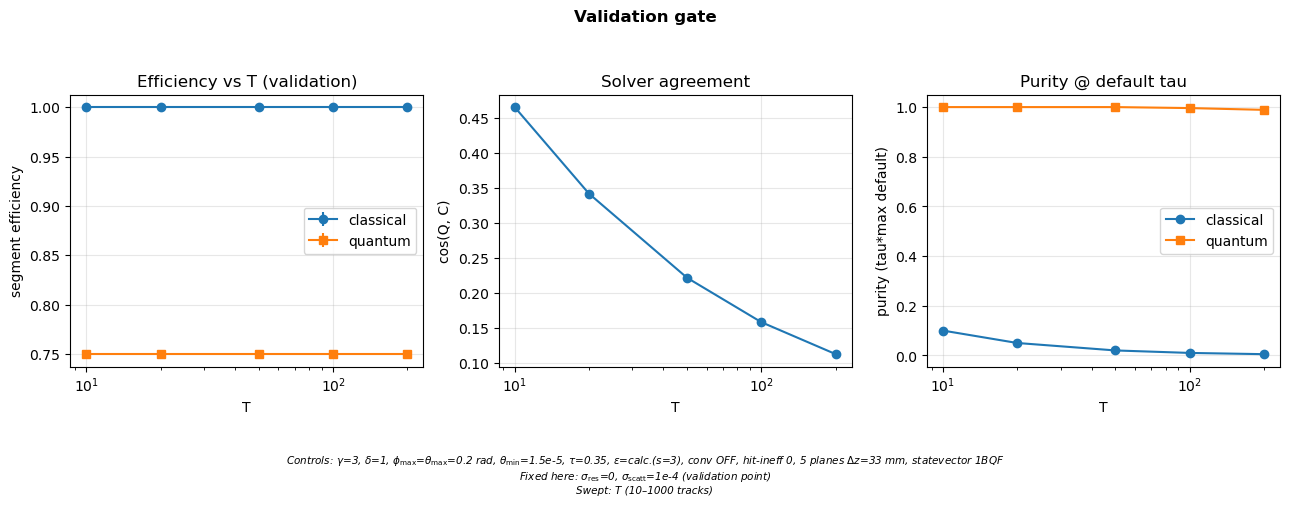

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].errorbar(g['n_trk'], g['effC_mean'], yerr=g['effC_sem'], marker='o', label='classical')
axes[0].errorbar(g['n_trk'], g['effQ_mean'], yerr=g['effQ_sem'], marker='s', label='quantum')
axes[0].set_xscale('log'); axes[0].set_xlabel('T'); axes[0].set_ylabel('segment efficiency')
axes[0].set_title('Efficiency vs T (validation)'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].errorbar(g['n_trk'], g['cos_mean'], yerr=g['cos_sem'], marker='o')
axes[1].set_xscale('log'); axes[1].set_xlabel('T'); axes[1].set_ylabel('cos(Q, C)')
axes[1].set_title('Solver agreement'); axes[1].grid(alpha=.3)
axes[2].plot(g['n_trk'], g['purC_mean'], 'o-', label='classical')
axes[2].plot(g['n_trk'], g['purQ_mean'], 's-', label='quantum')
axes[2].set_xscale('log'); axes[2].set_xlabel('T'); axes[2].set_ylabel('purity (tau*max default)')
axes[2].set_title('Purity @ default tau'); axes[2].legend(); axes[2].grid(alpha=.3)
fig.suptitle("Validation gate", fontweight='bold', y=1.05)
fig.text(0.5, -0.06,
         controls_caption(swept="T (10–1000 tracks)",
                          extra=r"$\sigma_{\rm res}$=0, $\sigma_{\rm scatt}$=1e-4 (validation point)"),
         ha='center', va='top', fontsize=7.5, style='italic')
plt.tight_layout(); plt.show()


## Histogram-based threshold check (single-event diagnostics)

For the validation point at the highest T, plot true-pair / false-pair score distributions to confirm the calculated $\varepsilon$ separates them.

In [5]:
import pickle
pkl_files = sorted((HERE/'results'/'validation').glob('eps2val_n1000_r000.pkl'))
if pkl_files:
    r = pickle.load(open(pkl_files[0],'rb'))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    bins = np.linspace(0, max(r['false_angles'].max(), r['true_angles'].max())*1.05, 80)
    axes[0].hist(r['false_angles'], bins=bins, alpha=.5, label=f"false ({len(r['false_angles'])})", color='tab:red')
    axes[0].hist(r['true_angles'],  bins=bins, alpha=.6, label=f"true ({len(r['true_angles'])})",  color='tab:green')
    axes[0].axvline(r['epsilon'], color='k', ls='--', label=f"eps={r['epsilon']:.2e}")
    axes[0].set_yscale('log'); axes[0].set_xlabel('pair angle (rad)'); axes[0].legend(); axes[0].set_title('Pair-angle histogram')
    # solver score histogram
    sol_C = r['sol_C']; sol_Q = r['sol_Q']; truth = r['truth']
    axes[1].hist(sol_C[~truth], bins=80, alpha=.5, label='false (C)', color='tab:red')
    axes[1].hist(sol_C[truth],  bins=80, alpha=.6, label='true (C)',  color='tab:green')
    axes[1].set_xlabel('classical score'); axes[1].set_yscale('log'); axes[1].legend(); axes[1].set_title('Classical solver scores')
    fig.suptitle("Single-event threshold diagnostics", fontweight='bold', y=1.05)
    fig.text(0.5, -0.06,
             controls_caption(swept="(none — single event)",
                              extra=rf"validation point $\sigma_{{\rm res}}$=0, $\sigma_{{\rm scatt}}$=1e-4, "
                                    rf"T=1000, rep 0, $\varepsilon$={r['epsilon']:.2e}"),
             ha='center', va='top', fontsize=7.5, style='italic')
    plt.tight_layout(); plt.show()
else:
    print('No validation pkl at T=1000 yet.')


No validation pkl at T=1000 yet.


## Sensitivity grid

In [6]:
sens = ev[ev['tag'].str.startswith('eps2_sr', na=False)].copy()
G = sens.groupby(['sigma_res','sigma_scatt','n_trk']).agg(
    effC=('cls_default_segment_efficiency','mean'),
    effQ=('q_default_segment_efficiency','mean'),
    angle_eff=('angle_segment_efficiency','mean'),
    angle_false=('angle_segment_false_rate','mean'),
    cosQC=('cos_QC','mean'),
    epsilon=('epsilon','first'),
    n=('rep','count'),
).reset_index()
G

,sigma_res,sigma_scatt,n_trk,effC,effQ,angle_eff,angle_false,cosQC,epsilon,n
0,0.00,0.0001,10.0,1.000000,0.750000,1.000000,0.000000,0.465084,0.000425,10
1,0.00,0.0001,20.0,1.000000,0.750000,1.000000,0.000000,0.341575,0.000425,10
2,0.00,0.0001,50.0,1.000000,0.750000,1.000000,0.000000,0.221326,0.000425,10
3,0.00,0.0001,100.0,1.000000,0.750000,1.000000,0.000000,0.157812,0.000425,5
4,0.00,0.0001,200.0,1.000000,0.750000,1.000000,0.004640,0.112330,0.000425,5
5,0.00,0.0003,10.0,1.000000,0.750000,1.000000,0.000000,0.465084,0.001273,10
6,0.00,0.0003,20.0,1.000000,0.750000,1.000000,0.000000,0.341575,0.001273,10
7,0.00,0.0003,50.0,1.000000,0.750000,1.000000,0.003965,0.221771,0.001273,10
8,0.00,0.0003,100.0,1.000000,0.750000,1.000000,0.015069,0.159056,0.001273,5
9,0.00,0.0003,200.0,1.000000,0.750250,1.000000,0.051824,0.115344,0.001273,5


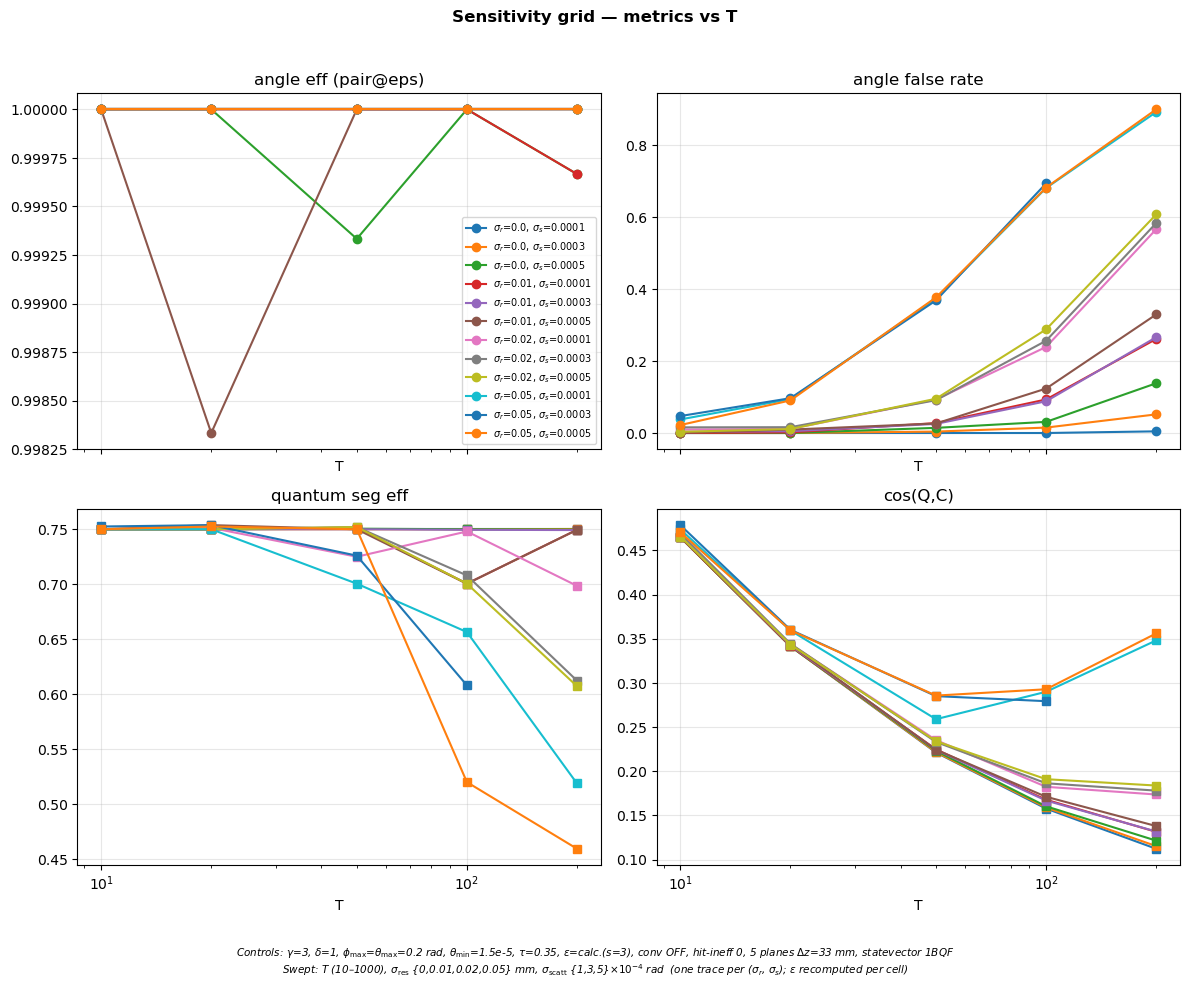

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
for (sr, ss), sub in G.groupby(['sigma_res','sigma_scatt']):
    lab = f"$\\sigma_r$={sr}, $\\sigma_s$={ss}"
    axes[0,0].plot(sub['n_trk'], sub['angle_eff'],  marker='o', label=lab)
    axes[0,1].plot(sub['n_trk'], sub['angle_false'],marker='o', label=lab)
    axes[1,0].plot(sub['n_trk'], sub['effQ'],       marker='s', label=lab)
    axes[1,1].plot(sub['n_trk'], sub['cosQC'],      marker='s', label=lab)
for ax, t in zip(axes.ravel(), ['angle eff (pair@eps)', 'angle false rate', 'quantum seg eff', 'cos(Q,C)']):
    ax.set_xscale('log'); ax.set_xlabel('T'); ax.set_title(t); ax.grid(alpha=.3)
axes[0,0].legend(fontsize=7, loc='best')
fig.suptitle("Sensitivity grid — metrics vs T", fontweight='bold', y=1.02)
fig.text(0.5, -0.02,
         controls_caption(swept=r"T (10–1000), $\sigma_{\rm res}$ {0,0.01,0.02,0.05} mm, "
                                r"$\sigma_{\rm scatt}$ {1,3,5}$\times10^{-4}$ rad  "
                                r"(one trace per ($\sigma_r$, $\sigma_s$); $\varepsilon$ recomputed per cell)"),
         ha='center', va='top', fontsize=7.5, style='italic')
plt.tight_layout(); plt.show()


## Segment-level metrics vs $\sigma_{\rm res}$ / $\sigma_{\rm scatt}$ — per $T$

Re-aggregates directly from raw pickles (the cached CSVs do not yet cover
$T \in \{100, 200, 500, 1000\}$). For each track count we plot the four
segment-level quantities (classical + quantum efficiency, purity, false rate,
plus the solver agreement $\cos(s_Q, s_C)$) as a function of each noise axis.

In [8]:
import pickle
from pathlib import Path

def _f(v):
    """None-safe float (some pickles store cos_QC / metrics as None)."""
    return float(v) if v is not None else np.nan

def _load_eps2_events(results_root: Path) -> pd.DataFrame:
    """Build an events DataFrame straight from raw pickles (includes high-T)."""
    rows = []
    for pf in sorted(results_root.rglob('*.pkl')):
        try:
            r = pickle.load(open(pf, 'rb'))
        except Exception:
            continue
        if r.get('status') != 'ok':
            continue
        cm = r.get('classical_metrics_default') or {}
        qm = r.get('quantum_metrics_default') or {}
        am = r.get('angle_metrics') or {}
        rows.append(dict(
            n_trk=int(r['n_trk']), rep=int(r['rep']),
            tag=str(r['tag']),
            sigma_res=_f(r['sigma_res']),
            sigma_scatt=_f(r['sigma_scatt']),
            epsilon=_f(r['epsilon']),
            cos_QC=_f(r.get('cos_QC')),
            cls_eff=_f(cm.get('segment_efficiency')),
            cls_pur=_f(cm.get('segment_purity')),
            cls_fr =_f(cm.get('segment_false_rate')),
            q_eff=_f(qm.get('segment_efficiency')),
            q_pur=_f(qm.get('segment_purity')),
            q_fr =_f(qm.get('segment_false_rate')),
            ang_eff=_f(am.get('segment_efficiency')),
            ang_fr =_f(am.get('segment_false_rate')),
        ))
    return pd.DataFrame(rows)

ev_all = _load_eps2_events(HERE / 'results')
print(f"loaded {len(ev_all)} events; per-T counts:")
print(ev_all.groupby('n_trk').size().to_string())


loaded 1120 events; per-T counts:
n_trk
2       60
4       30
5       30
6       30
8       30
10     190
15      30
20     190
30      20
40      20
50     170
60      20
75      20
100    105
150     10
200     85
300     10
400     39
500      5
700     21
750      5


In [9]:
# Aggregate sensitivity rows by (n_trk, sigma_res, sigma_scatt)
sens_ev = ev_all[ev_all['tag'].str.startswith('eps2_sr')].copy()

def _sem(x):
    x = x.dropna()
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0

metric_cols = ['cls_eff','cls_pur','cls_fr','q_eff','q_pur','q_fr','cos_QC','ang_eff','ang_fr']
spec = {f"{c}_mean": (c, 'mean') for c in metric_cols}
spec.update({f"{c}_sem": (c, _sem) for c in metric_cols})
spec['n_reps'] = ('rep', 'count')

G = (sens_ev.groupby(['n_trk','sigma_res','sigma_scatt'])
              .agg(**spec)
              .reset_index()
              .sort_values(['n_trk','sigma_res','sigma_scatt']))
print('cells per T:'); print(G.groupby('n_trk').size().to_string())
G.head()

cells per T:
n_trk
10     12
20     12
50     12
100    12
200    12
400    12
700     6


,n_trk,sigma_res,sigma_scatt,cls_eff_mean,cls_pur_mean,cls_fr_mean,q_eff_mean,q_pur_mean,q_fr_mean,cos_QC_mean,...,cls_eff_sem,cls_pur_sem,cls_fr_sem,q_eff_sem,q_pur_sem,q_fr_sem,cos_QC_sem,ang_eff_sem,ang_fr_sem,n_reps
0,10,0.00,0.0001,1.0,0.1,0.9,0.75,1.00000,0.00000,0.465084,...,0.0,0.0,0.0,0.0,0.00000,0.00000,3.700743e-17,0.0,0.000000,10
1,10,0.00,0.0003,1.0,0.1,0.9,0.75,1.00000,0.00000,0.465084,...,0.0,0.0,0.0,0.0,0.00000,0.00000,3.411917e-17,0.0,0.000000,10
2,10,0.00,0.0005,1.0,0.1,0.9,0.75,1.00000,0.00000,0.465084,...,0.0,0.0,0.0,0.0,0.00000,0.00000,3.559261e-17,0.0,0.000000,10
3,10,0.01,0.0001,1.0,0.1,0.9,0.75,1.00000,0.00000,0.465084,...,0.0,0.0,0.0,0.0,0.00000,0.00000,3.700743e-17,0.0,0.000000,10
4,10,0.01,0.0003,1.0,0.1,0.9,0.75,0.99375,0.00625,0.465798,...,0.0,0.0,0.0,0.0,0.00625,0.00625,7.137982e-04,0.0,0.003226,10


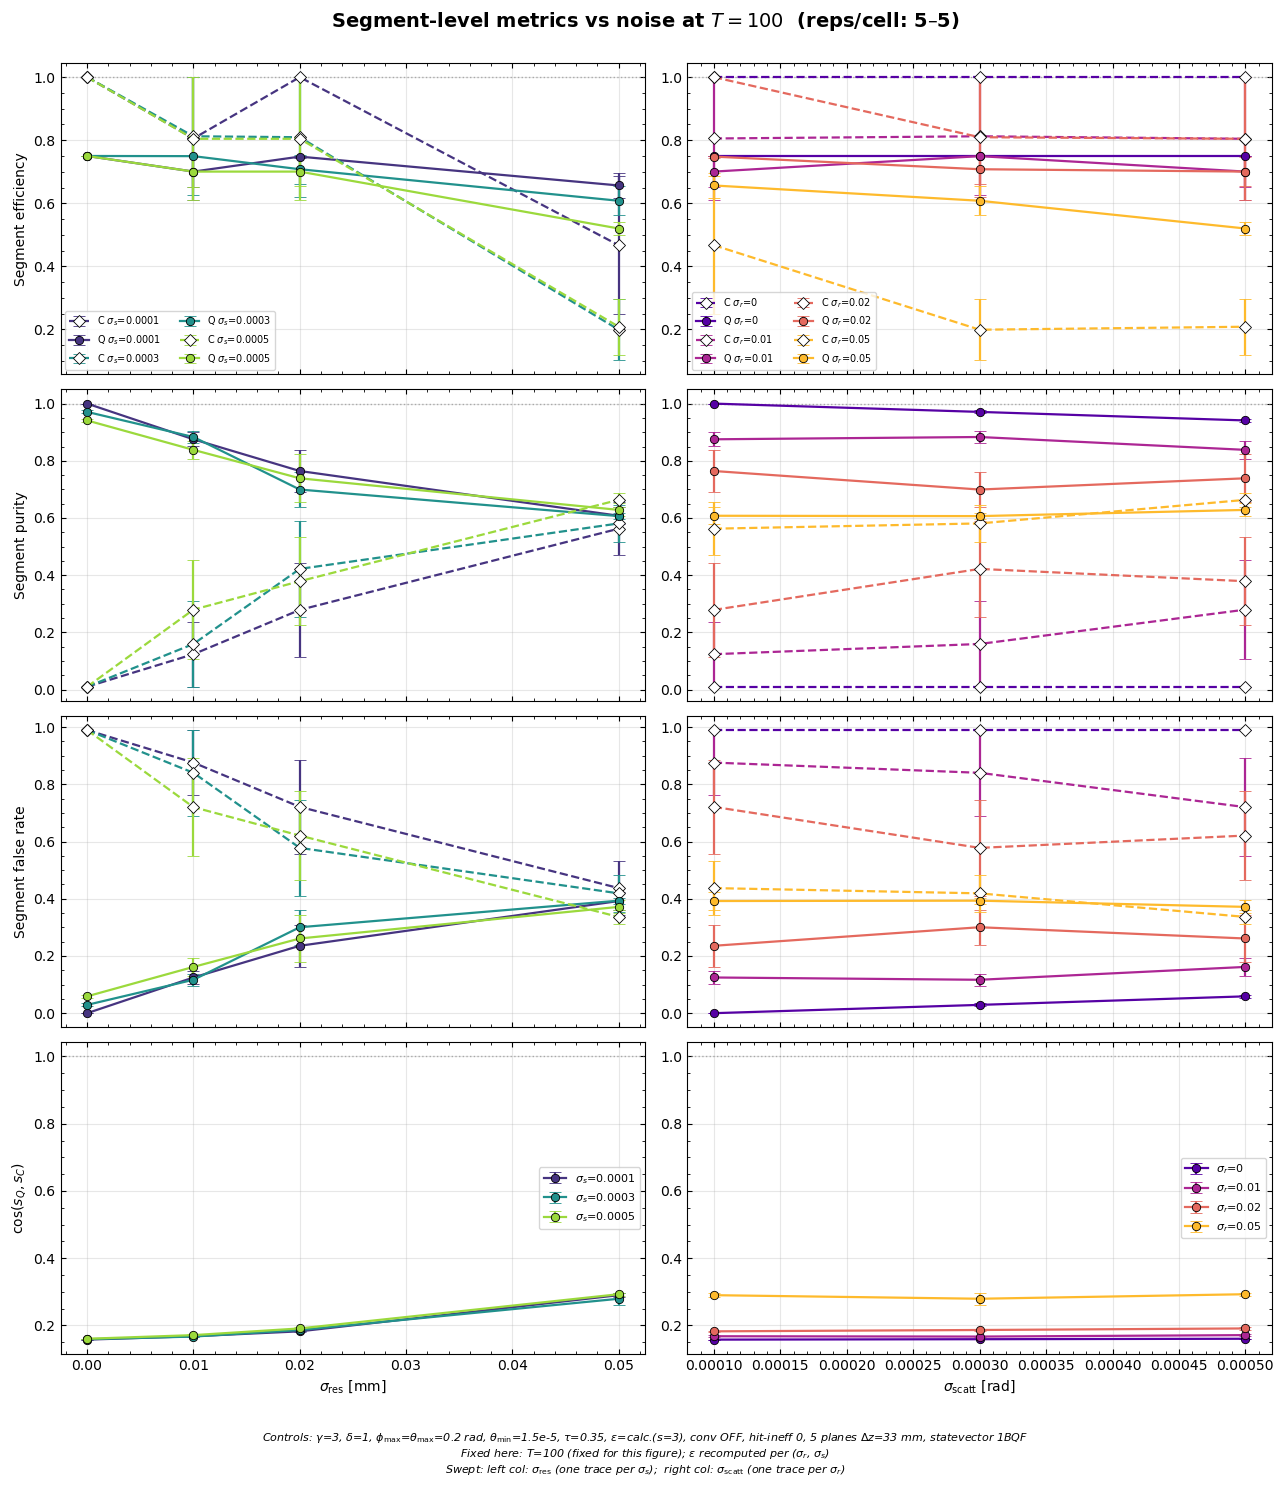

  T=100: saved → /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Epsilon_study_2/figures/sigma_sensitivity/sigma_sensitivity_T0100.pdf


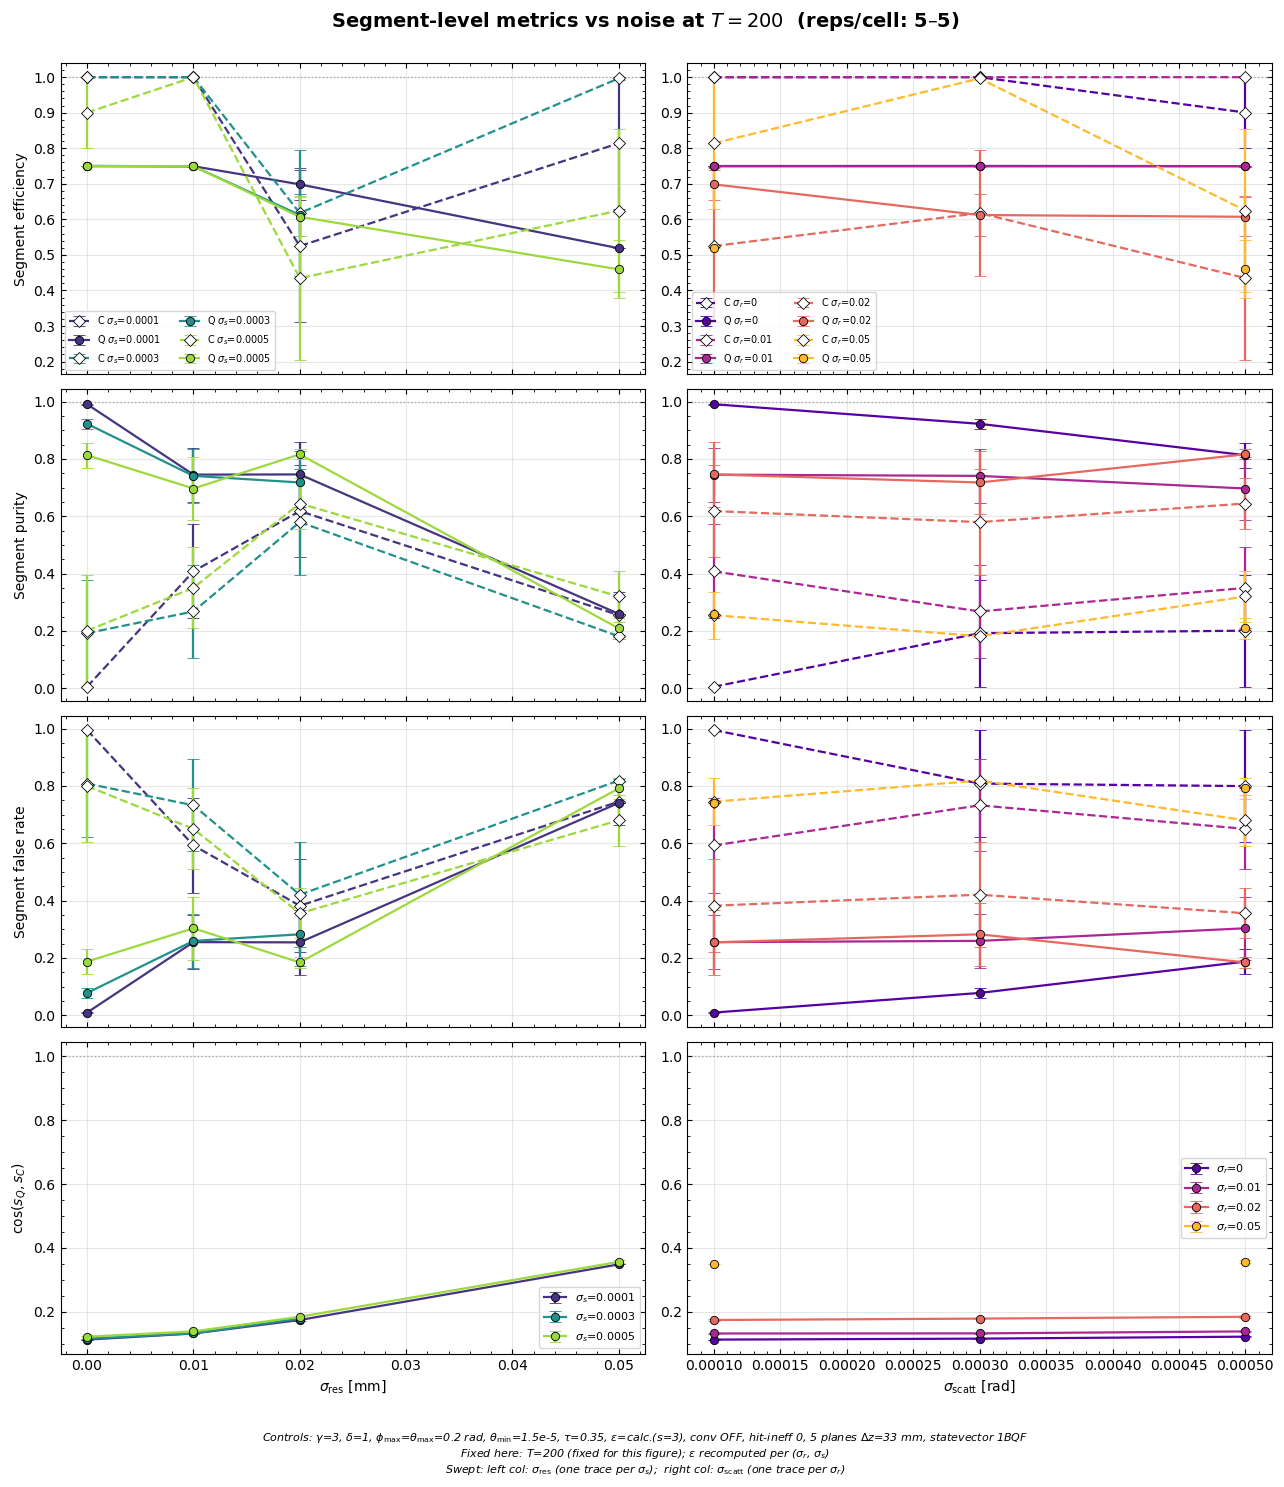

  T=200: saved → /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Epsilon_study_2/figures/sigma_sensitivity/sigma_sensitivity_T0200.pdf
  T=500: no data — skipping
  T=1000: no data — skipping


In [10]:
# ── per-T plotting routine ─────────────────────────────────────────────────
TARGET_TS = [100, 200, 500, 1000]
FIGDIR = HERE / 'figures' / 'sigma_sensitivity'
FIGDIR.mkdir(parents=True, exist_ok=True)

def _err(ax, x, y_mean, y_sem, fmt, color, label, mfc=None):
    kw = dict(fmt=fmt, color=color, capsize=4, capthick=1.0,
              markeredgecolor='black', markeredgewidth=0.6,
              lw=1.6, ms=6, label=label, zorder=3)
    if mfc is not None:
        kw['mfc'] = mfc
    ax.errorbar(x, y_mean, yerr=y_sem, **kw)

def _plot_T(T, sub, savepath=None):
    """For one T, plot 4 metrics × 2 noise axes (sigma_res, sigma_scatt)."""
    if sub.empty:
        print(f"  T={T}: no data — skipping")
        return None
    fig, axes = plt.subplots(4, 2, figsize=(13, 14), sharex='col')
    sscatt_vals = sorted(sub['sigma_scatt'].unique())
    sres_vals   = sorted(sub['sigma_res'].unique())
    cmap_ss = plt.cm.viridis(np.linspace(0.15, 0.85, max(len(sscatt_vals), 2)))
    cmap_sr = plt.cm.plasma (np.linspace(0.15, 0.85, max(len(sres_vals), 2)))

    # column 0 — vs sigma_res, one trace per sigma_scatt
    for ss, c in zip(sscatt_vals, cmap_ss):
        s = sub[sub['sigma_scatt'] == ss].sort_values('sigma_res')
        lbl = rf"$\sigma_s$={ss:g}"
        _err(axes[0,0], s['sigma_res'], s['cls_eff_mean'], s['cls_eff_sem'], 'D--', c, f"C {lbl}", mfc='white')
        _err(axes[0,0], s['sigma_res'], s['q_eff_mean'],   s['q_eff_sem'],   'o-',  c, f"Q {lbl}")
        _err(axes[1,0], s['sigma_res'], s['cls_pur_mean'], s['cls_pur_sem'], 'D--', c, None, mfc='white')
        _err(axes[1,0], s['sigma_res'], s['q_pur_mean'],   s['q_pur_sem'],   'o-',  c, None)
        _err(axes[2,0], s['sigma_res'], s['cls_fr_mean'],  s['cls_fr_sem'],  'D--', c, None, mfc='white')
        _err(axes[2,0], s['sigma_res'], s['q_fr_mean'],    s['q_fr_sem'],    'o-',  c, None)
        _err(axes[3,0], s['sigma_res'], s['cos_QC_mean'],  s['cos_QC_sem'],  'o-',  c, lbl)

    # column 1 — vs sigma_scatt, one trace per sigma_res
    for sr, c in zip(sres_vals, cmap_sr):
        s = sub[sub['sigma_res'] == sr].sort_values('sigma_scatt')
        lbl = rf"$\sigma_r$={sr:g}"
        _err(axes[0,1], s['sigma_scatt'], s['cls_eff_mean'], s['cls_eff_sem'], 'D--', c, f"C {lbl}", mfc='white')
        _err(axes[0,1], s['sigma_scatt'], s['q_eff_mean'],   s['q_eff_sem'],   'o-',  c, f"Q {lbl}")
        _err(axes[1,1], s['sigma_scatt'], s['cls_pur_mean'], s['cls_pur_sem'], 'D--', c, None, mfc='white')
        _err(axes[1,1], s['sigma_scatt'], s['q_pur_mean'],   s['q_pur_sem'],   'o-',  c, None)
        _err(axes[2,1], s['sigma_scatt'], s['cls_fr_mean'],  s['cls_fr_sem'],  'D--', c, None, mfc='white')
        _err(axes[2,1], s['sigma_scatt'], s['q_fr_mean'],    s['q_fr_sem'],    'o-',  c, None)
        _err(axes[3,1], s['sigma_scatt'], s['cos_QC_mean'],  s['cos_QC_sem'],  'o-',  c, lbl)

    ylabels = ['Segment efficiency', 'Segment purity', 'Segment false rate', r'$\cos(s_Q, s_C)$']
    for i, yl in enumerate(ylabels):
        axes[i,0].set_ylabel(yl)
        for j in (0, 1):
            axes[i,j].grid(alpha=0.3); axes[i,j].minorticks_on()
            axes[i,j].tick_params(which='both', direction='in', top=True, right=True)
    axes[-1,0].set_xlabel(r'$\sigma_{\rm res}$ [mm]')
    axes[-1,1].set_xlabel(r'$\sigma_{\rm scatt}$ [rad]')
    axes[0,0].legend(fontsize=7, loc='lower left', ncol=2)
    axes[0,1].legend(fontsize=7, loc='lower left', ncol=2)
    axes[3,0].legend(fontsize=8, loc='best')
    axes[3,1].legend(fontsize=8, loc='best')

    for ax in (axes[0,0], axes[0,1], axes[1,0], axes[1,1], axes[3,0], axes[3,1]):
        ax.axhline(1.0, color='gray', ls=':', lw=1, alpha=0.6)

    n_reps_min = int(sub['n_reps'].min())
    n_reps_max = int(sub['n_reps'].max())
    fig.suptitle(rf"Segment-level metrics vs noise at $T={T}$"
                 rf"  (reps/cell: {n_reps_min}–{n_reps_max})",
                 y=1.00, fontweight='bold', fontsize=14)
    fig.text(0.5, -0.015,
             controls_caption(swept=rf"left col: $\sigma_{{\rm res}}$ (one trace per $\sigma_s$);  "
                                    rf"right col: $\sigma_{{\rm scatt}}$ (one trace per $\sigma_r$)",
                              extra=rf"T={T} (fixed for this figure); "
                                    rf"$\varepsilon$ recomputed per ($\sigma_r$, $\sigma_s$)"),
             ha='center', va='top', fontsize=8, style='italic')
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath.with_suffix('.pdf'), dpi=600, bbox_inches='tight', facecolor='white')
        fig.savefig(savepath.with_suffix('.png'), dpi=200, bbox_inches='tight', facecolor='white')
    return fig

for T in TARGET_TS:
    sub = G[G['n_trk'] == T].copy()
    fig = _plot_T(T, sub, savepath=FIGDIR / f"sigma_sensitivity_T{T:04d}")
    if fig is not None:
        plt.show()
        print(f"  T={T}: saved → {FIGDIR / f'sigma_sensitivity_T{T:04d}.pdf'}")


## 3-D phase-space view: metrics over (σ_res, σ_scatt)

Each panel is a surface over the full $(\sigma_{\rm res},\,\sigma_{\rm scatt})$ grid at fixed $T$.  
Blue surface = Classical solver; Orange surface = Quantum solver (where applicable).

  T=10: saved → /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Epsilon_study_2/figures/sigma_sensitivity_3d/sigma_sensitivity_3d_T0010


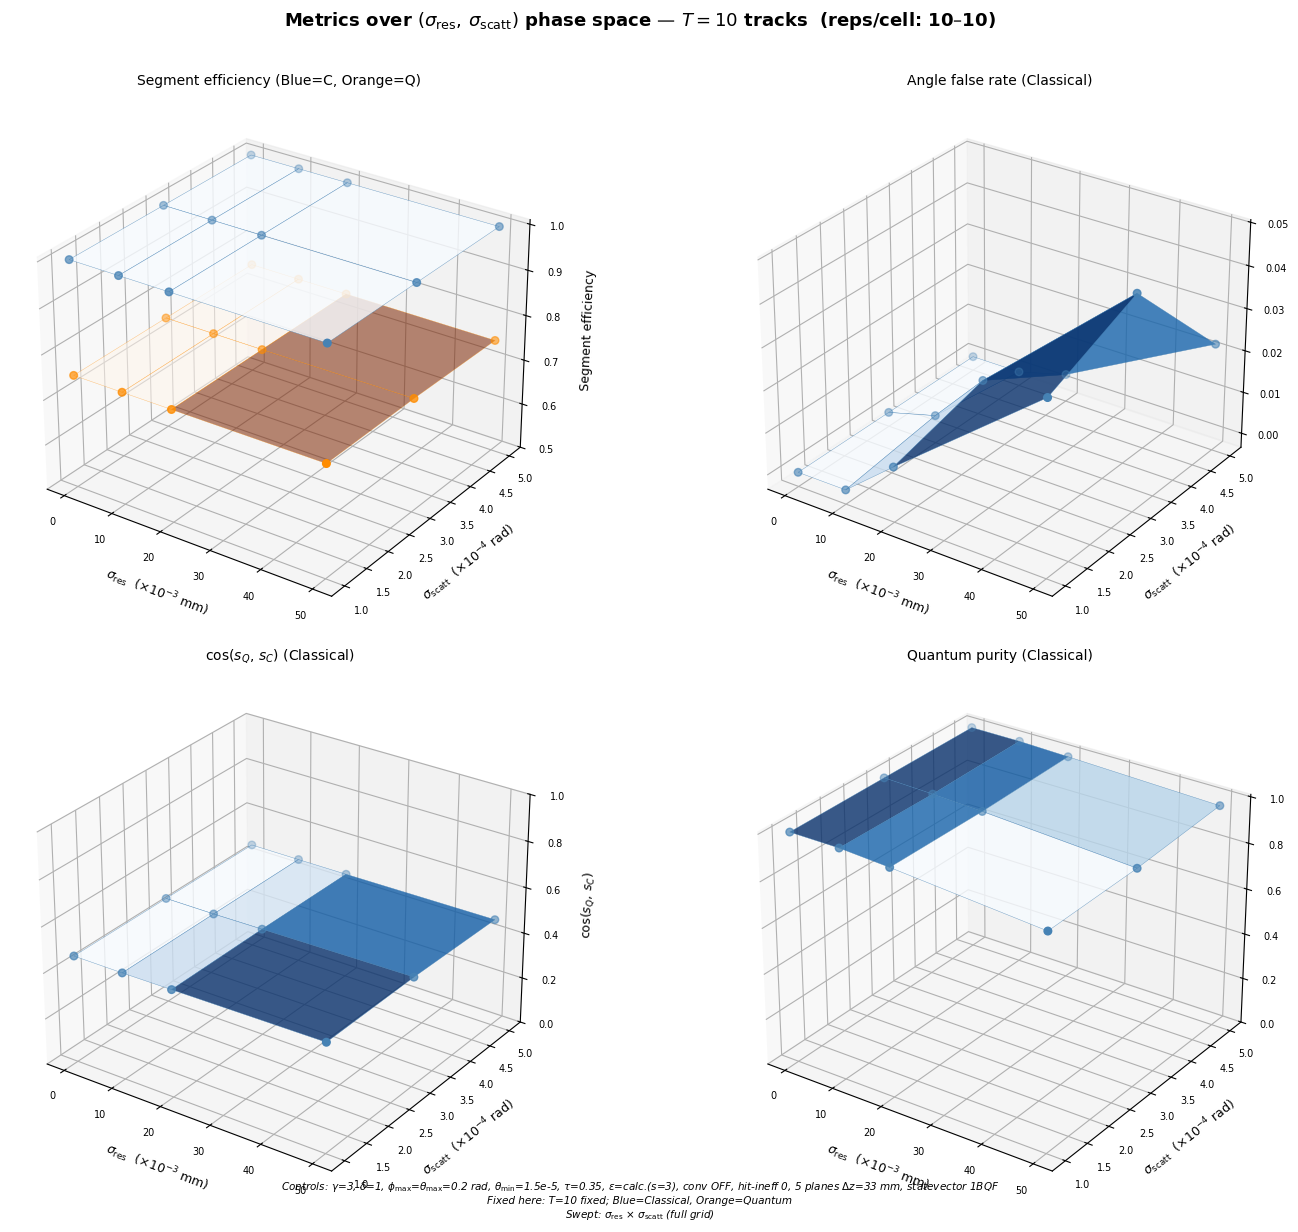

  T=20: saved → /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Epsilon_study_2/figures/sigma_sensitivity_3d/sigma_sensitivity_3d_T0020


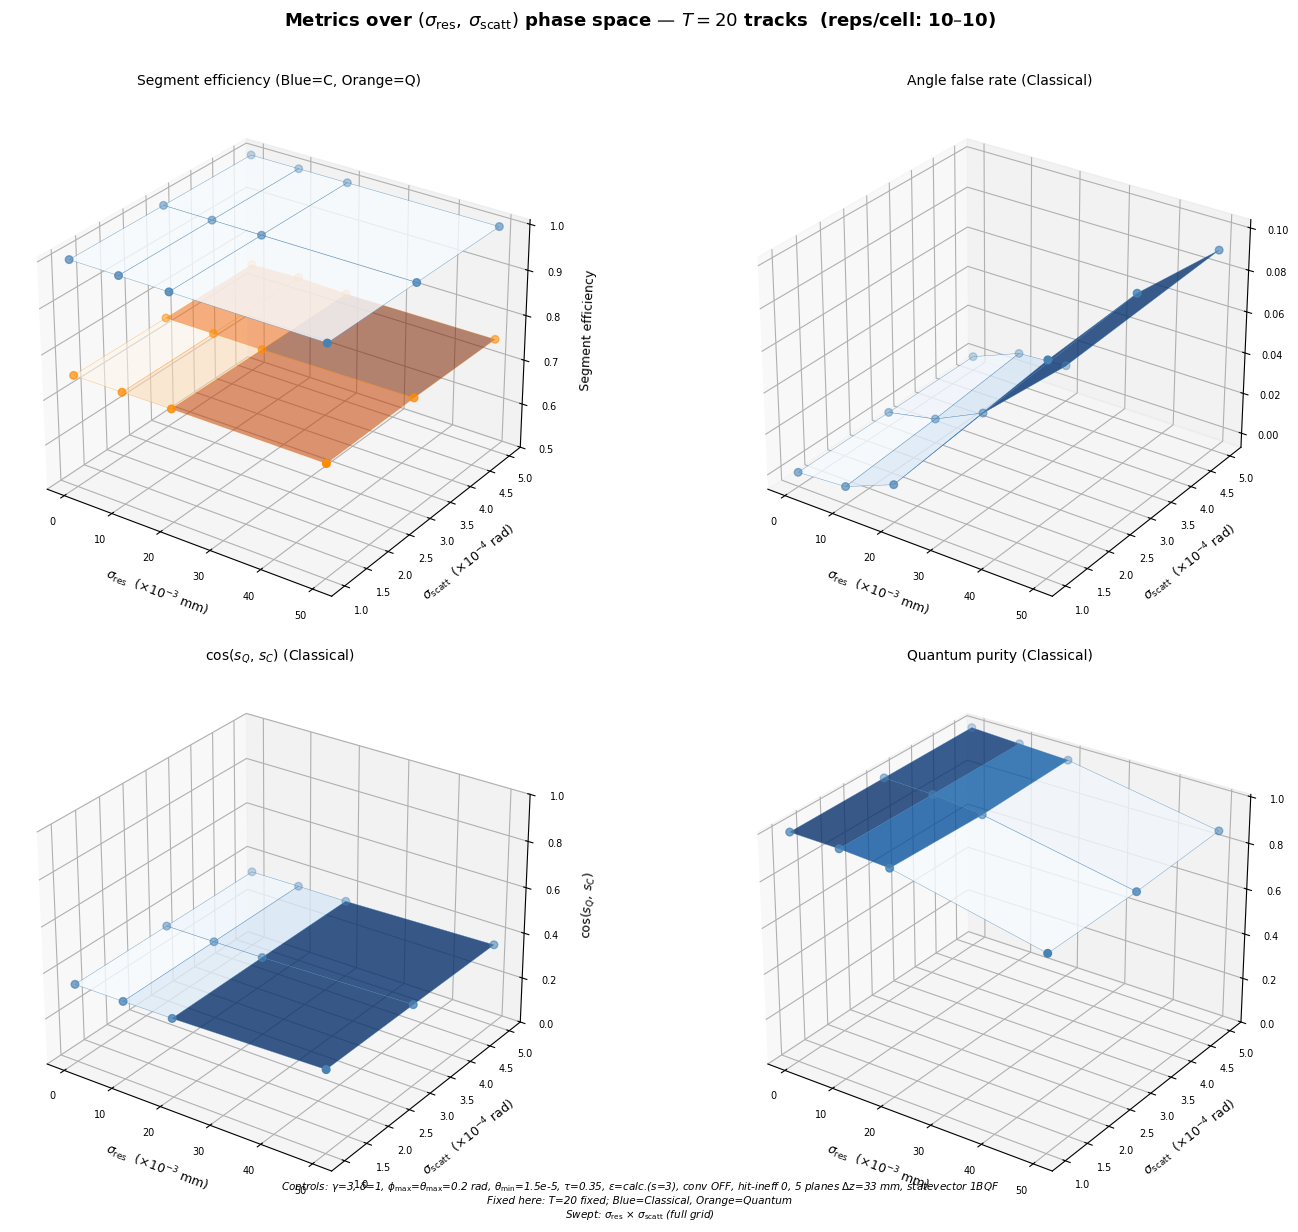

  T=50: saved → /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Epsilon_study_2/figures/sigma_sensitivity_3d/sigma_sensitivity_3d_T0050


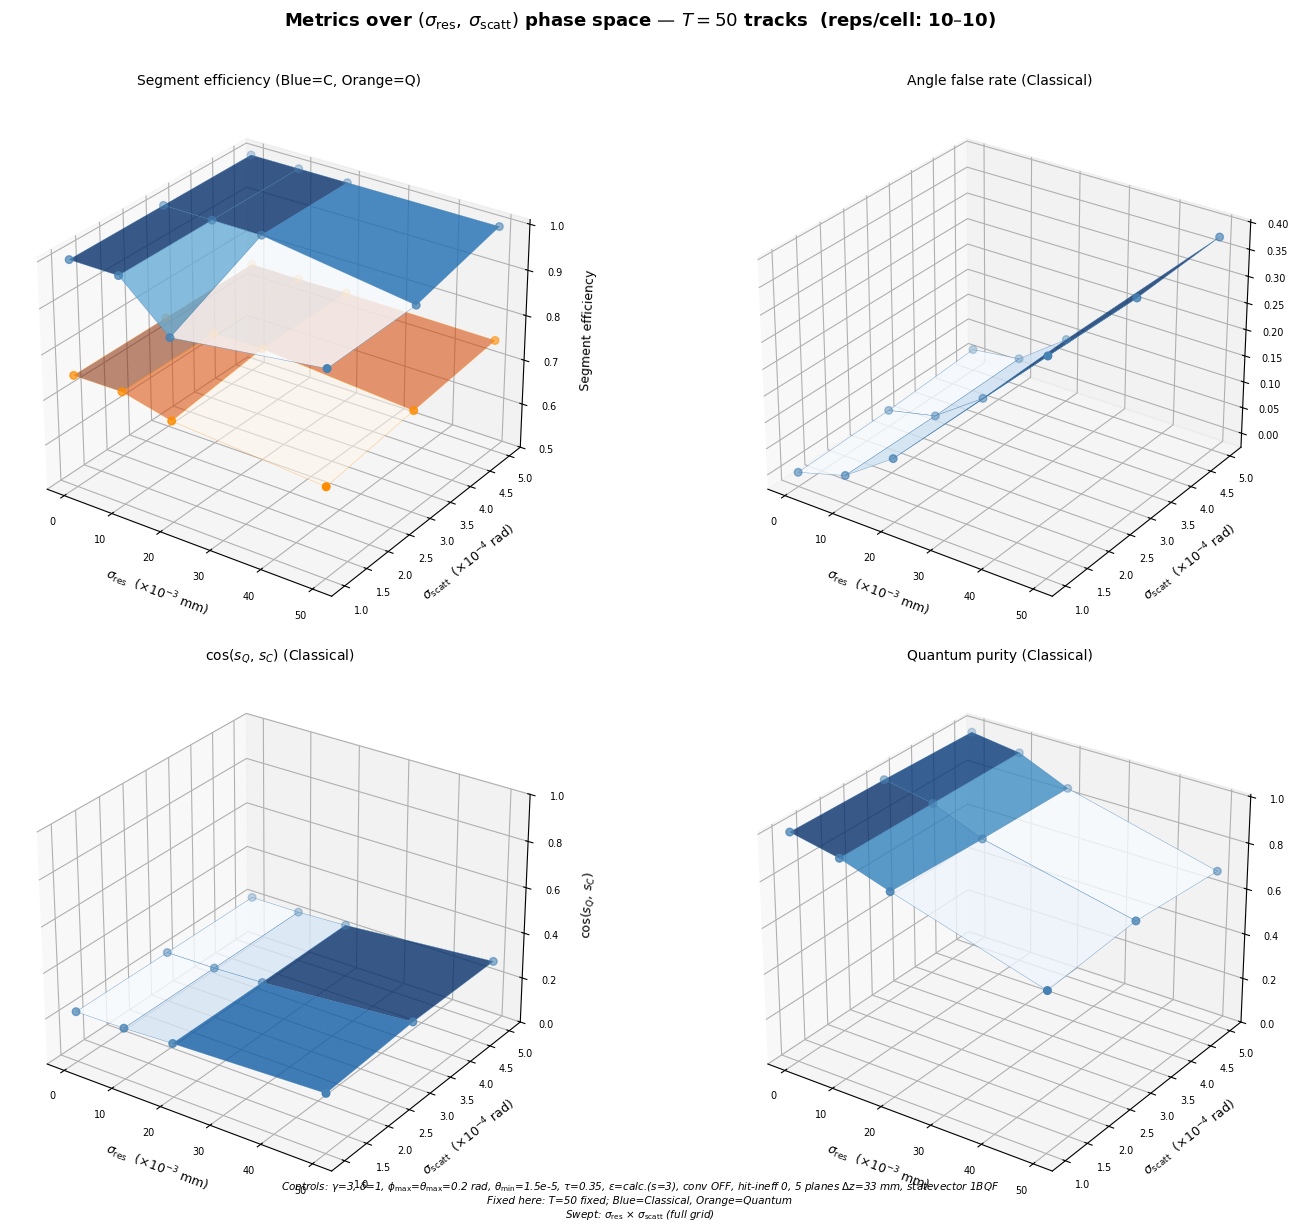

  T=100: saved → /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Epsilon_study_2/figures/sigma_sensitivity_3d/sigma_sensitivity_3d_T0100


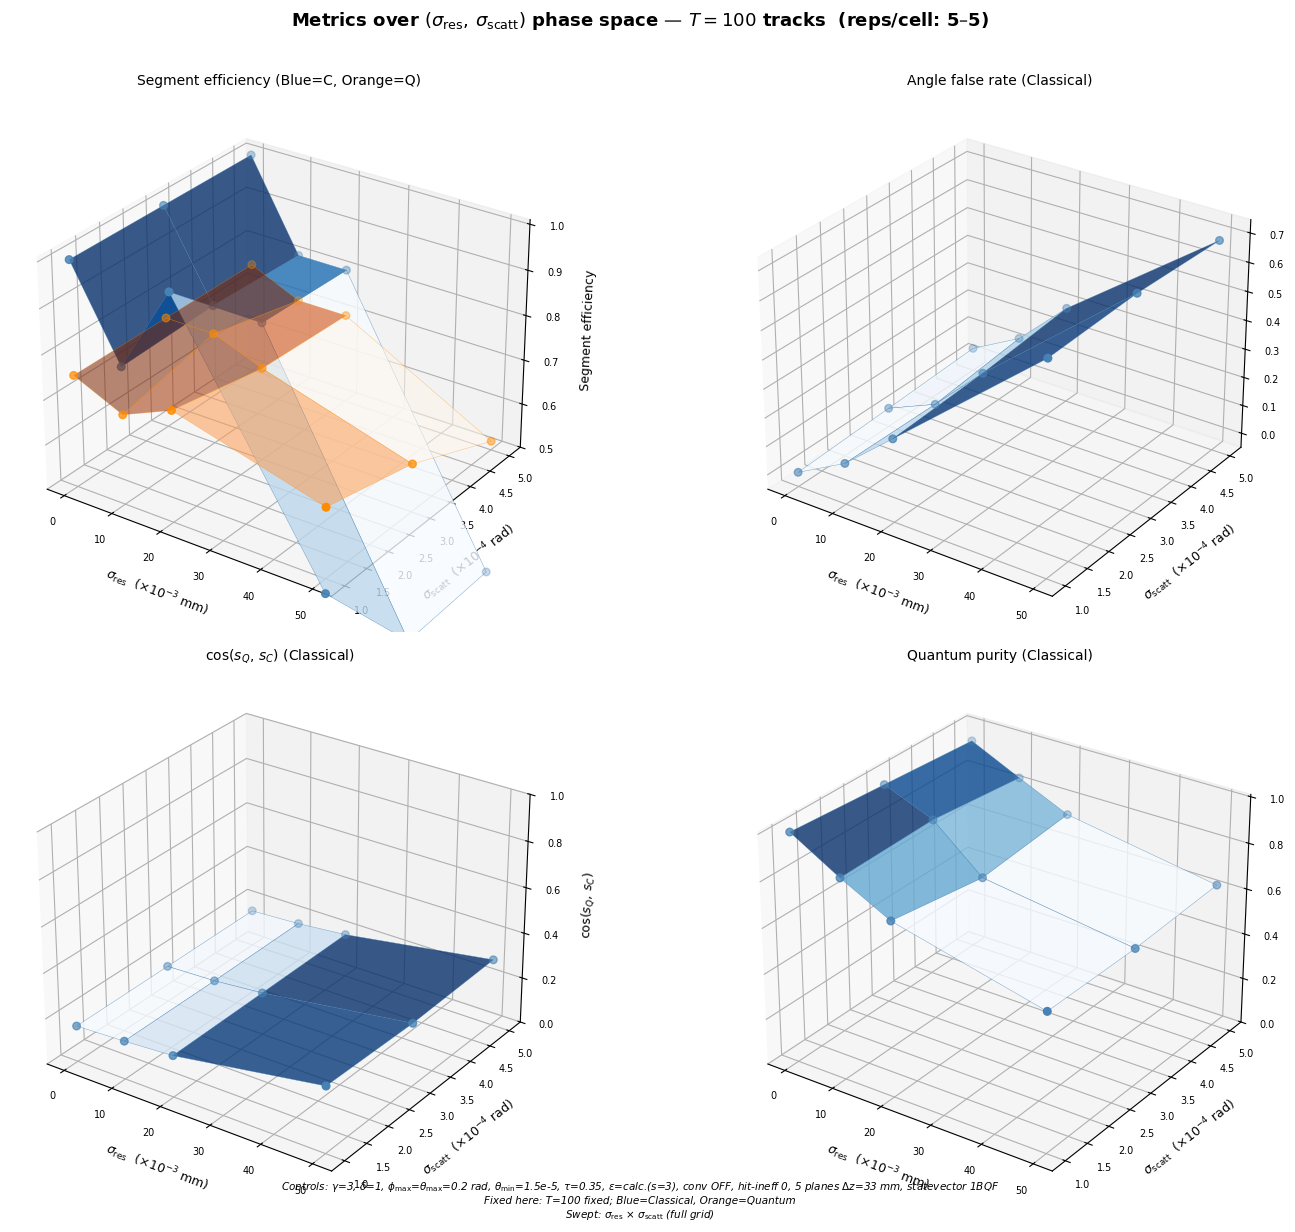

  T=200: saved → /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Epsilon_study_2/figures/sigma_sensitivity_3d/sigma_sensitivity_3d_T0200


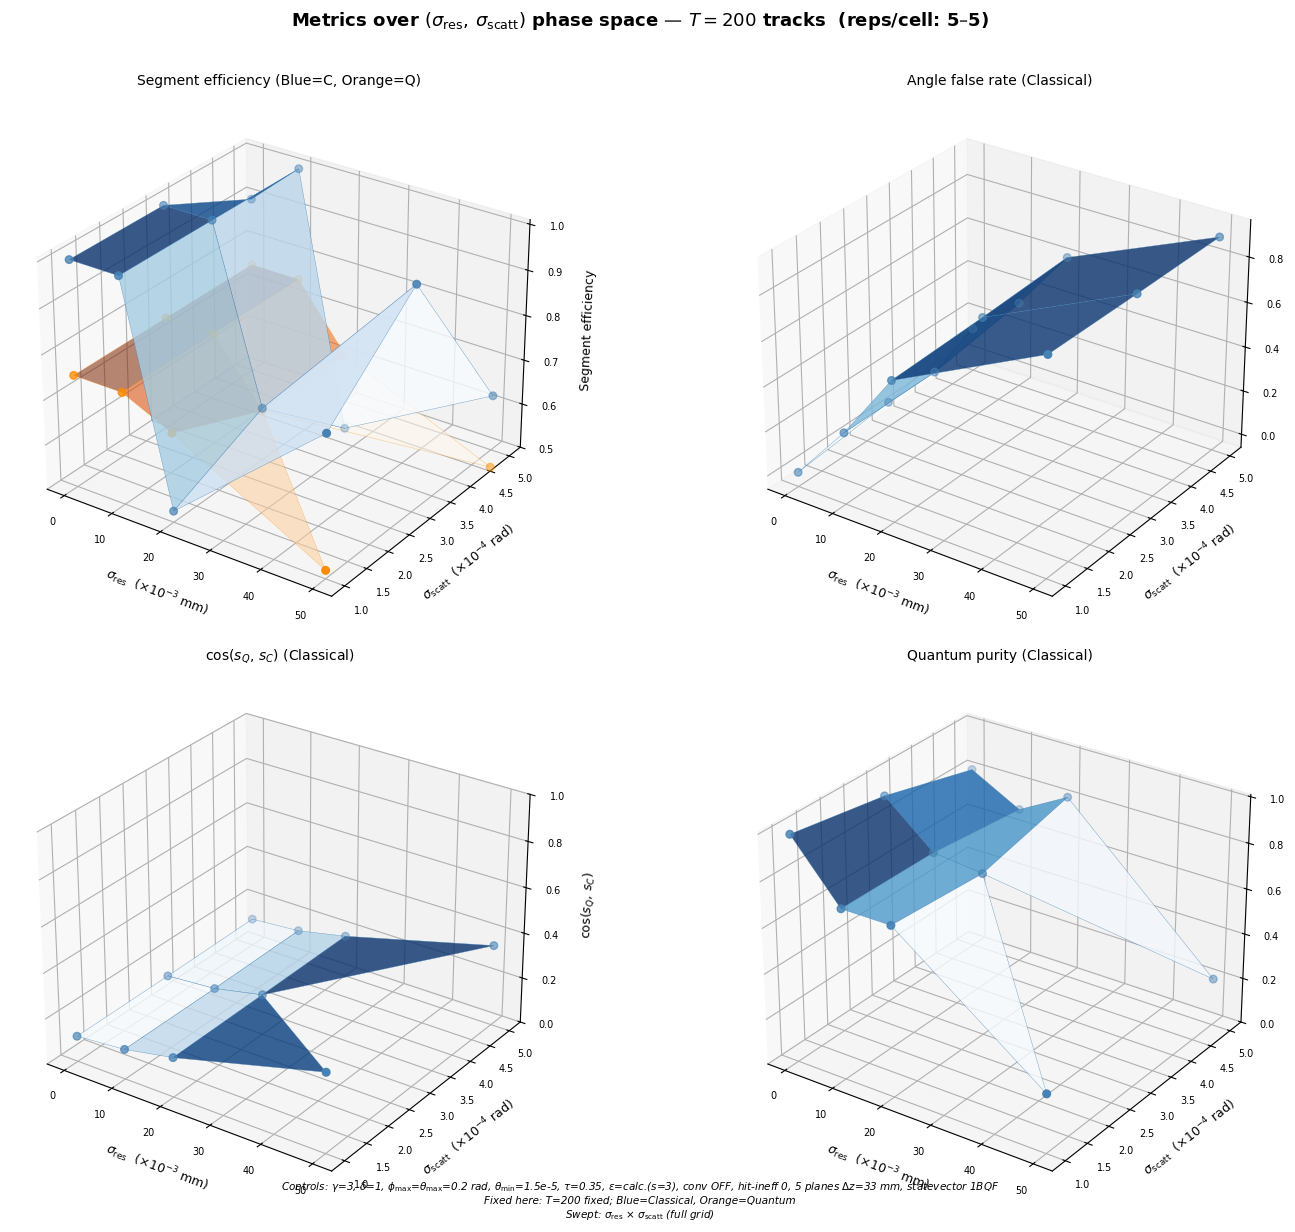

In [11]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

FIGDIR_3D = HERE / 'figures' / 'sigma_sensitivity_3d'
FIGDIR_3D.mkdir(parents=True, exist_ok=True)

# (col_classical, col_quantum_or_None, z-label, (zmin, zmax))
METRICS_3D = [
    ('cls_eff', 'q_eff', 'Segment efficiency',  (0.5,  1.01)),
    ('ang_fr',  None,    'Angle false rate',     (None, None)),
    ('cos_QC',  None,    r'$\cos(s_Q,\,s_C)$',  (0.0,  1.0 )),
    ('q_pur',   None,    'Quantum purity',       (0.0,  1.01)),
]

def _plot_T_3d(T, sub, savepath=None):
    """3-D surface of each metric over the (σ_res, σ_scatt) phase space."""
    if sub.empty:
        print(f"  T={T}: no data — skipping"); return None
    sres   = np.array(sorted(sub['sigma_res'].unique()),   float)
    sscatt = np.array(sorted(sub['sigma_scatt'].unique()), float)
    if len(sres) < 2 or len(sscatt) < 2:
        print(f"  T={T}: too few grid points — skipping"); return None

    SR, SS = np.meshgrid(sres, sscatt, indexing='ij')

    def _grid(col):
        Z = np.full(SR.shape, np.nan)
        for i, sr in enumerate(sres):
            for j, ss in enumerate(sscatt):
                row = sub[(sub['sigma_res'] == sr) & (sub['sigma_scatt'] == ss)]
                if not row.empty:
                    Z[i, j] = float(row[f'{col}_mean'].iloc[0])
        return Z

    fig = plt.figure(figsize=(16, 12))

    for idx, (mc, mq, title, zlim) in enumerate(METRICS_3D):
        ax = fig.add_subplot(2, 2, idx + 1, projection='3d')

        ZC = _grid(mc)
        ZQ = _grid(mq) if mq else None

        ax.plot_surface(SR * 1e3, SS * 1e4, ZC,
                        cmap='Blues', alpha=0.8, edgecolor='steelblue', linewidth=0.3)
        ax.scatter(SR.ravel() * 1e3, SS.ravel() * 1e4, ZC.ravel(),
                   color='steelblue', s=30, depthshade=True, zorder=5)

        if ZQ is not None:
            ax.plot_surface(SR * 1e3, SS * 1e4, ZQ,
                            cmap='Oranges', alpha=0.55, edgecolor='darkorange', linewidth=0.3)
            ax.scatter(SR.ravel() * 1e3, SS.ravel() * 1e4, ZQ.ravel(),
                       color='darkorange', s=30, depthshade=True, zorder=5)

        ax.set_xlabel(r'$\sigma_{\rm res}$  ($\times10^{-3}$ mm)', labelpad=6, fontsize=9)
        ax.set_ylabel(r'$\sigma_{\rm scatt}$  ($\times10^{-4}$ rad)', labelpad=6, fontsize=9)
        ax.set_zlabel(title, labelpad=6, fontsize=9)
        suffix = ' (Blue=C, Orange=Q)' if mq else ' (Classical)'
        ax.set_title(title + suffix, fontsize=10)
        if zlim[0] is not None: ax.set_zlim(bottom=zlim[0])
        if zlim[1] is not None: ax.set_zlim(top=zlim[1])
        ax.tick_params(labelsize=7)
        ax.view_init(elev=28, azim=-55)

    n_min = int(sub['n_reps'].min()); n_max = int(sub['n_reps'].max())
    fig.suptitle(
        rf"Metrics over $(\sigma_{{\rm res}},\,\sigma_{{\rm scatt}})$ phase space"
        rf" — $T = {T}$ tracks  (reps/cell: {n_min}–{n_max})",
        fontweight='bold', fontsize=13, y=1.01)
    fig.text(0.5, 0.0,
             controls_caption(
                 swept=r"$\sigma_{\rm res}$ × $\sigma_{\rm scatt}$ (full grid)",
                 extra=f"T={T} fixed; Blue=Classical, Orange=Quantum"),
             ha='center', va='bottom', fontsize=7.5, style='italic')
    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath.with_suffix('.pdf'), dpi=300, bbox_inches='tight', facecolor='white')
        fig.savefig(savepath.with_suffix('.png'), dpi=150, bbox_inches='tight', facecolor='white')
        print(f"  T={T}: saved → {savepath}")
    return fig

for T in [10, 20, 50, 100, 200]:
    sub = G[G['n_trk'] == T].copy()
    fig = _plot_T_3d(T, sub, savepath=FIGDIR_3D / f"sigma_sensitivity_3d_T{T:04d}")
    if fig is not None:
        plt.show()

## 1-D noise scans

Each plot sweeps one noise axis while holding the other at its minimum (lowest-noise) value, showing how the model's segment metrics degrade as that single noise source is turned up.  
One trace per $T$; solid lines = Classical, dashed = Quantum (where applicable).

saved → /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Epsilon_study_2/figures/noise_scans/scan_sigma_res.pdf/png


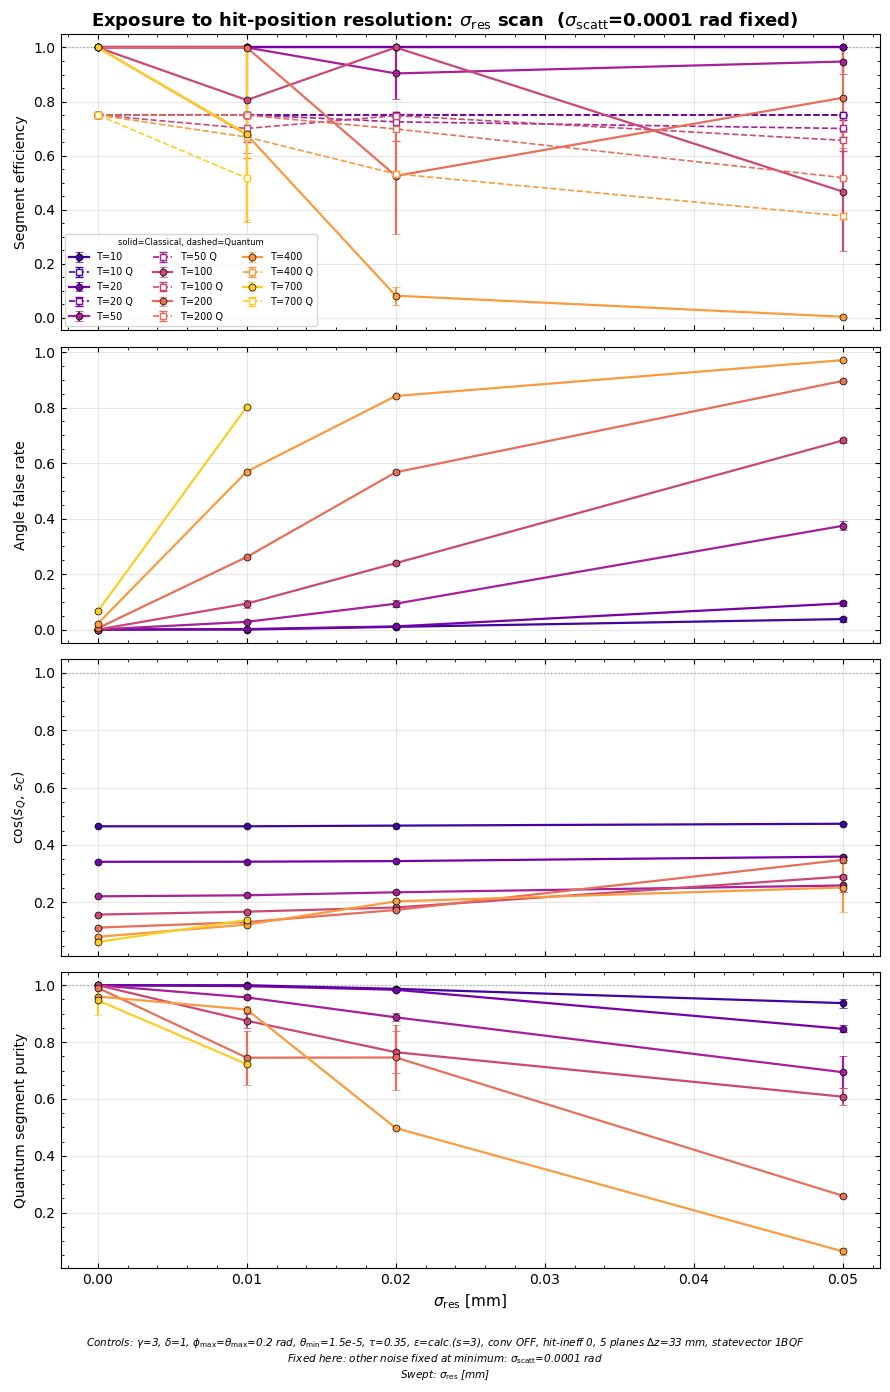

saved → /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Epsilon_study_2/figures/noise_scans/scan_sigma_scatt.pdf/png


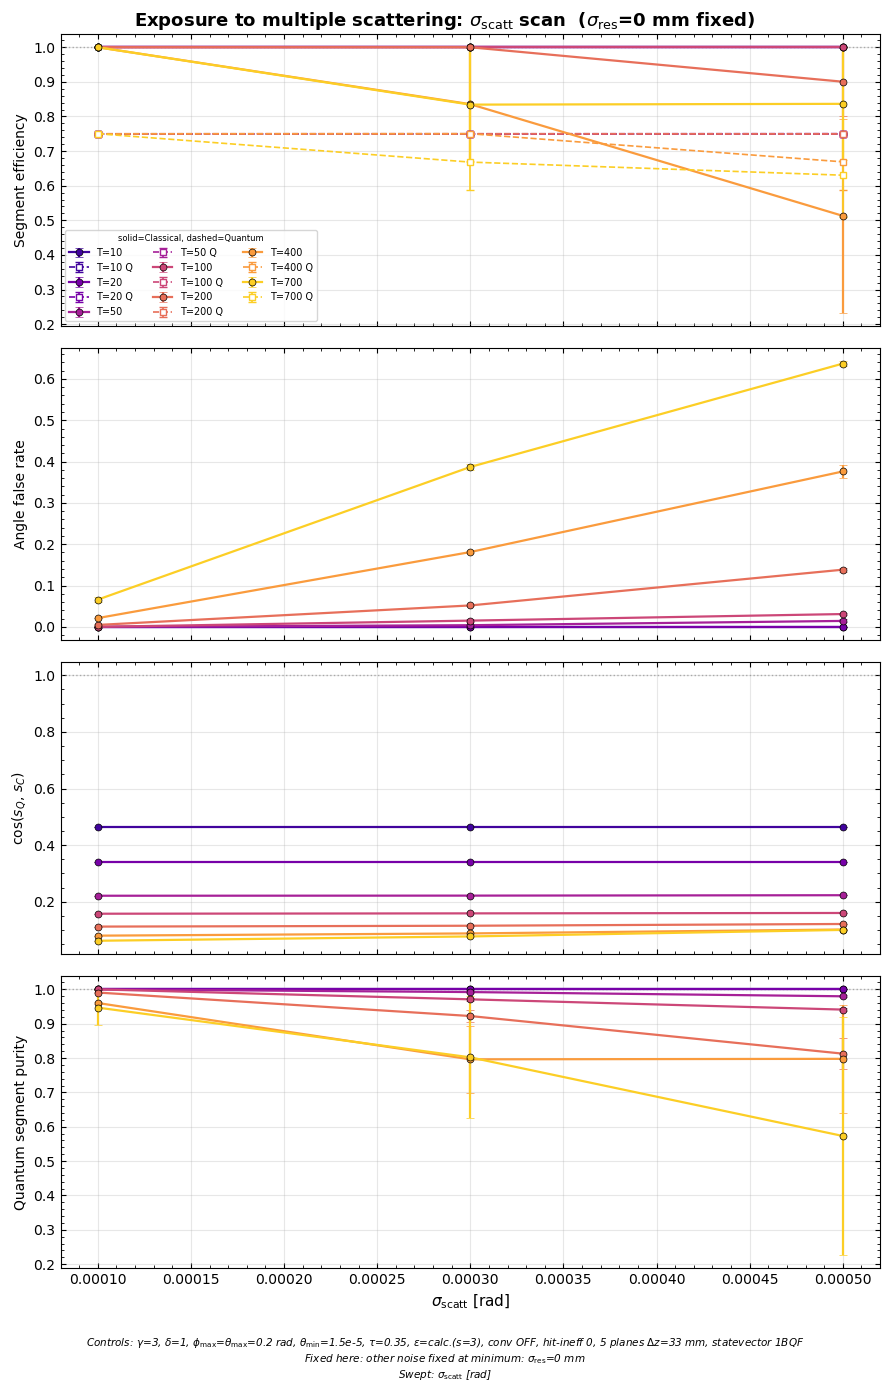

In [12]:
FIGDIR_SCAN = HERE / 'figures' / 'noise_scans'
FIGDIR_SCAN.mkdir(parents=True, exist_ok=True)

SS_LOW = float(sorted(G['sigma_scatt'].unique())[0])   # 1e-4 rad — minimum scattering
SR_LOW = float(sorted(G['sigma_res'].unique())[0])     # 0.0 mm  — minimum resolution

# Metrics to display per scan panel
SCAN_METRICS = [
    ('cls_eff', 'q_eff', 'Segment efficiency',        True ),
    ('ang_fr',  None,    'Angle false rate',           False),
    ('cos_QC',  None,    r'$\cos(s_Q,\,s_C)$',        True ),
    ('q_pur',   None,    'Quantum segment purity',     True ),
]

T_VALS  = sorted(G['n_trk'].unique())
cmap_T  = plt.cm.plasma(np.linspace(0.1, 0.9, max(len(T_VALS), 2)))

def _scan_plot(scan_col, fixed_col, fixed_val, xlabel, title, savepath=None):
    """Metrics vs one noise axis; the other axis is pinned at fixed_val."""
    sub = G[np.isclose(G[fixed_col], fixed_val)].copy()

    fig, axes = plt.subplots(len(SCAN_METRICS), 1, figsize=(9, 14), sharex=True)

    for ax, (mc, mq, ylabel, draw_ref) in zip(axes, SCAN_METRICS):
        for T, c in zip(T_VALS, cmap_T):
            d = sub[sub['n_trk'] == T].sort_values(scan_col)
            if d.empty:
                continue
            lbl = f"T={T}"
            ax.errorbar(d[scan_col], d[f'{mc}_mean'], yerr=d[f'{mc}_sem'],
                        fmt='o-', color=c, capsize=3, lw=1.6, ms=5,
                        markeredgecolor='black', markeredgewidth=0.5,
                        label=lbl, zorder=3)
            if mq is not None:
                ax.errorbar(d[scan_col], d[f'{mq}_mean'], yerr=d[f'{mq}_sem'],
                            fmt='s--', color=c, capsize=3, lw=1.2, ms=5,
                            mfc='white', mec=c, label=f"{lbl} Q", zorder=3)
        if draw_ref:
            ax.axhline(1.0, color='gray', ls=':', lw=1, alpha=0.6)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(alpha=0.3)
        ax.minorticks_on()
        ax.tick_params(which='both', direction='in', top=True, right=True)

    axes[0].legend(fontsize=7, ncol=3, loc='best',
                   title='solid=Classical, dashed=Quantum', title_fontsize=6)
    axes[-1].set_xlabel(xlabel, fontsize=11)

    fixed_str = (rf"$\sigma_{{\rm scatt}}$={fixed_val:g} rad"
                 if fixed_col == 'sigma_scatt'
                 else rf"$\sigma_{{\rm res}}$={fixed_val:g} mm")
    fig.suptitle(title, fontweight='bold', fontsize=13)
    fig.text(0.5, 0.0,
             controls_caption(swept=xlabel, extra=f"other noise fixed at minimum: {fixed_str}"),
             ha='center', va='bottom', fontsize=7.5, style='italic')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    if savepath is not None:
        for ext in ('pdf', 'png'):
            fig.savefig(savepath.with_suffix(f'.{ext}'), dpi=200,
                        bbox_inches='tight', facecolor='white')
        print(f"saved → {savepath}.pdf/png")
    return fig

# ── Scan 1: σ_res, σ_scatt held at minimum ────────────────────────────────
fig_sr = _scan_plot(
    scan_col='sigma_res', fixed_col='sigma_scatt', fixed_val=SS_LOW,
    xlabel=rf'$\sigma_{{\rm res}}$ [mm]',
    title=(rf'Exposure to hit-position resolution: $\sigma_{{\rm res}}$ scan'
           rf'  ($\sigma_{{\rm scatt}}$={SS_LOW:g} rad fixed)'),
    savepath=FIGDIR_SCAN / 'scan_sigma_res',
)
plt.show()

# ── Scan 2: σ_scatt, σ_res held at minimum ────────────────────────────────
fig_ss = _scan_plot(
    scan_col='sigma_scatt', fixed_col='sigma_res', fixed_val=SR_LOW,
    xlabel=rf'$\sigma_{{\rm scatt}}$ [rad]',
    title=(rf'Exposure to multiple scattering: $\sigma_{{\rm scatt}}$ scan'
           rf'  ($\sigma_{{\rm res}}$={SR_LOW:g} mm fixed)'),
    savepath=FIGDIR_SCAN / 'scan_sigma_scatt',
)
plt.show()

## Threshold-robust segment metrics vs noise

The hard-threshold impurity $\mathrm{FR}=N_\text{false act}/N_\text{active}$ is
misleading here: the false-segment pool grows $\sim T^2$, so it dwarfs the true
pool ($\sim 4\times10^6$ false vs $\sim 4\times10^3$ true at $T=1000$) and a tiny
per-segment leak inflates the impurity. We therefore report three metrics per
$(\sigma_{\rm res},\sigma_{\rm scatt},T)$ cell, for **both** the classical and the
1-bit-HHL (quantum) solver:

1. **Per-segment leakage** $p_\text{leak} = N_\text{false act}/N_\text{false all}$
   — the intrinsic probability that any given false segment is spuriously
   activated, with the combinatorial pool size factored out. Reported as a
   percentage. (Active = norm-matched solution $>\tau$, with $\tau=0.35$.)
2. **ROC-AUC** $= P(\text{sol[true]} > \text{sol[false]})$ via the rank-based
   Mann–Whitney $U$ statistic (ties = 0.5), threshold-free. AUC = 1 ⇒ a perfect
   separating threshold exists; AUC = 0.5 ⇒ no separation.
3. **Hard-threshold impurity** $\mathrm{FR}=N_\text{false act}/N_\text{active}$
   — shown only for contrast, to expose how the combinatorial pool distorts it.

All quantities are averaged over repetitions with standard error.


In [13]:
# ── compute threshold-robust metrics from the raw solution vectors ─────────
import pickle, glob

def _auc(scores, truth):
    """ROC-AUC = P(score[true] > score[false]) via rank-based Mann-Whitney U
    (average ranks within tie groups; ties count 0.5)."""
    scores = np.asarray(scores, float)
    truth  = np.asarray(truth, bool)
    n_t, n_f = int(truth.sum()), int((~truth).sum())
    if n_t == 0 or n_f == 0 or not np.isfinite(scores).all():
        return np.nan
    order  = np.argsort(scores, kind='mergesort')
    s_sort = scores[order]
    ranks_sorted = np.empty(len(scores), float)
    i, N = 0, len(scores)
    while i < N:                       # average ranks within tie groups
        j = i
        while j + 1 < N and s_sort[j + 1] == s_sort[i]:
            j += 1
        ranks_sorted[i:j + 1] = (i + j) / 2.0 + 1.0   # 1-based average rank
        i = j + 1
    ranks = np.empty(N, float)
    ranks[order] = ranks_sorted
    sum_ranks_true = ranks[truth].sum()
    return (sum_ranks_true - n_t * (n_t + 1) / 2.0) / (n_t * n_f)

def _pct_leak(m):   # N_false_active / N_false_all  (intrinsic per-segment leak)
    nfa = m.get('n_false_all')
    return 100.0 * m['n_false_active'] / nfa if nfa else np.nan

def _pct_impurity(m):  # N_false_active / N_active  (hard-threshold, misleading)
    na = m.get('n_active')
    return 100.0 * m['n_false_active'] / na if na else np.nan

def _load_eps2_informative():
    rows = []
    pdirs = [HERE / 'results' / 'sensitivity', HERE / 'results' / 'validation']
    for base in pdirs:
        for fp in sorted(glob.glob(str(base / '**' / '*.pkl'), recursive=True)):
            try:
                r = pickle.load(open(fp, 'rb'))
            except Exception:
                continue
            if r.get('status') != 'ok':
                continue
            cm, qm = r.get('classical_metrics_default'), r.get('quantum_metrics_default')
            tr = r.get('truth')
            if cm is None or qm is None or tr is None:
                continue
            rows.append(dict(
                n_trk=int(r['n_trk']), rep=int(r.get('rep', 0)),
                sigma_res=float(r['sigma_res']), sigma_scatt=float(r['sigma_scatt']),
                pleak_C=_pct_leak(cm),       pleak_Q=_pct_leak(qm),
                auc_C=_auc(r['sol_C'], tr),  auc_Q=_auc(r['sol_Q'], tr),
                fr_C=_pct_impurity(cm),      fr_Q=_pct_impurity(qm),
            ))
    return pd.DataFrame(rows)

inf_all = _load_eps2_informative()
print(f"loaded {len(inf_all)} events across "
      f"{inf_all['n_trk'].nunique()} T values, "
      f"{inf_all['sigma_res'].nunique()} sigma_res, "
      f"{inf_all['sigma_scatt'].nunique()} sigma_scatt")
inf_all.head()


loaded 561 events across 7 T values, 4 sigma_res, 3 sigma_scatt


,n_trk,rep,sigma_res,sigma_scatt,pleak_C,pleak_Q,auc_C,auc_Q,fr_C,fr_Q
0,10,0,0.01,0.0001,100.0,0.0,1.0,1.0,90.0,0.0
1,10,1,0.01,0.0001,100.0,0.0,1.0,1.0,90.0,0.0
2,10,2,0.01,0.0001,100.0,0.0,1.0,1.0,90.0,0.0
3,10,3,0.01,0.0001,100.0,0.0,1.0,1.0,90.0,0.0
4,10,4,0.01,0.0001,100.0,0.0,1.0,1.0,90.0,0.0


In [14]:
# ── aggregate over repetitions: mean +/- standard error per (T, sr, ss) ────
def _sem(x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0

_metrics = ['pleak_C', 'pleak_Q', 'auc_C', 'auc_Q', 'fr_C', 'fr_Q']
INF = (inf_all
       .groupby(['n_trk', 'sigma_res', 'sigma_scatt'])[_metrics]
       .agg(['mean', _sem])
       .reset_index())
INF.columns = ['n_trk', 'sigma_res', 'sigma_scatt'] + \
    [f'{m}_{s}' for m in _metrics for s in ('mean', 'sem')]
print("reps per cell:",
      inf_all.groupby(['n_trk', 'sigma_res', 'sigma_scatt']).size().describe()[['min', 'max']].to_dict())
INF.round(4)


reps per cell: {'min': 1.0, 'max': 20.0}


,n_trk,sigma_res,sigma_scatt,pleak_C_mean,pleak_C_sem,pleak_Q_mean,pleak_Q_sem,auc_C_mean,auc_C_sem,auc_Q_mean,auc_Q_sem,fr_C_mean,fr_C_sem,fr_Q_mean,fr_Q_sem
0,10,0.00,0.0001,100.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,90.0000,0.0000,0.0000,0.0000
1,10,0.00,0.0003,100.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,90.0000,0.0000,0.0000,0.0000
2,10,0.00,0.0005,100.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,90.0000,0.0000,0.0000,0.0000
3,10,0.01,0.0001,100.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,90.0000,0.0000,0.0000,0.0000
4,10,0.01,0.0003,100.0000,0.0000,0.0556,0.0556,1.0000,0.0000,0.9999,0.0001,90.0000,0.0000,0.6250,0.6250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,700,0.00,0.0001,80.0035,19.9965,0.0114,0.0028,1.0000,0.0000,0.9999,0.0000,82.0400,17.8172,9.3683,2.3313
72,700,0.00,0.0003,33.3350,33.3325,0.0455,0.0437,0.9999,0.0001,0.9996,0.0000,34.7260,32.5658,19.7901,17.7483
73,700,0.00,0.0005,50.0031,49.9969,0.1864,0.1800,1.0000,0.0000,0.9991,0.0000,53.8938,45.9634,42.6877,34.6336
74,700,0.01,0.0001,0.0023,0.0000,0.0284,0.0000,0.9998,0.0000,0.9977,0.0000,26.7857,0.0000,27.7584,0.0000


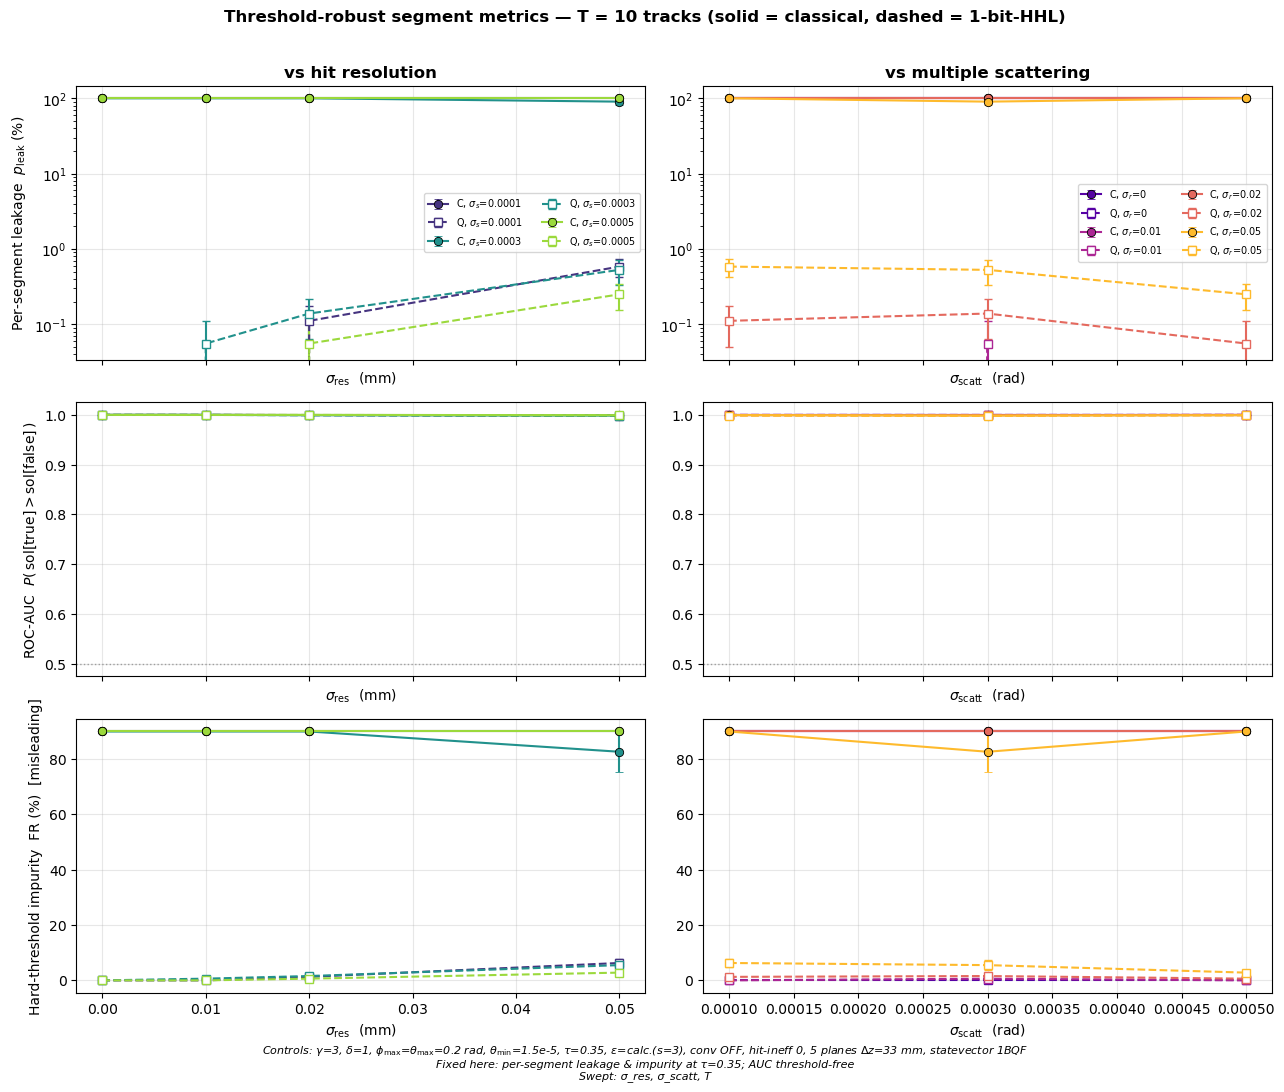

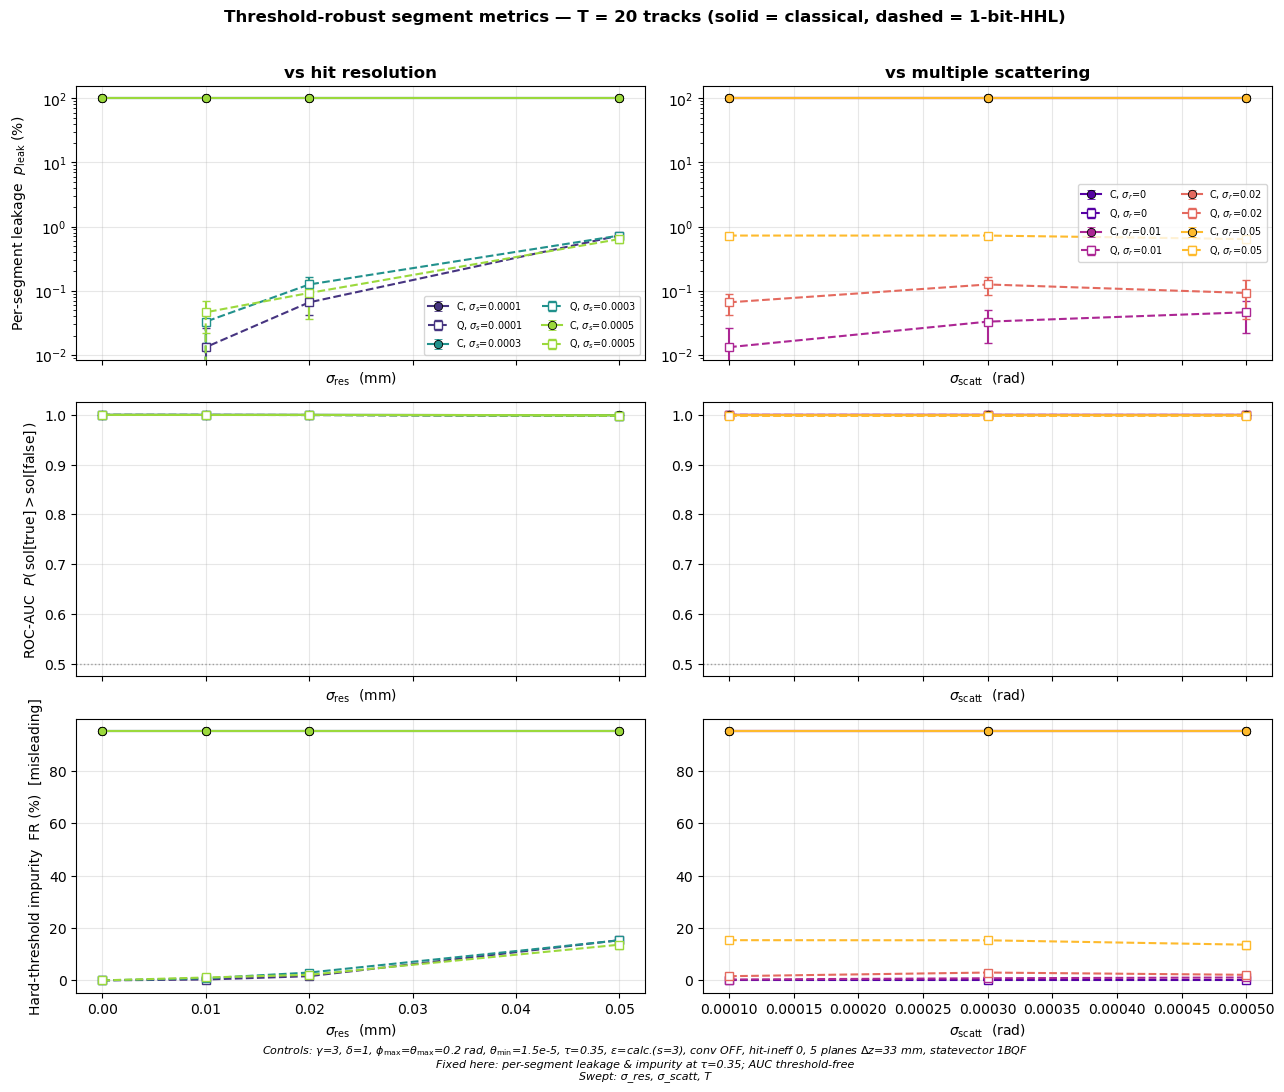

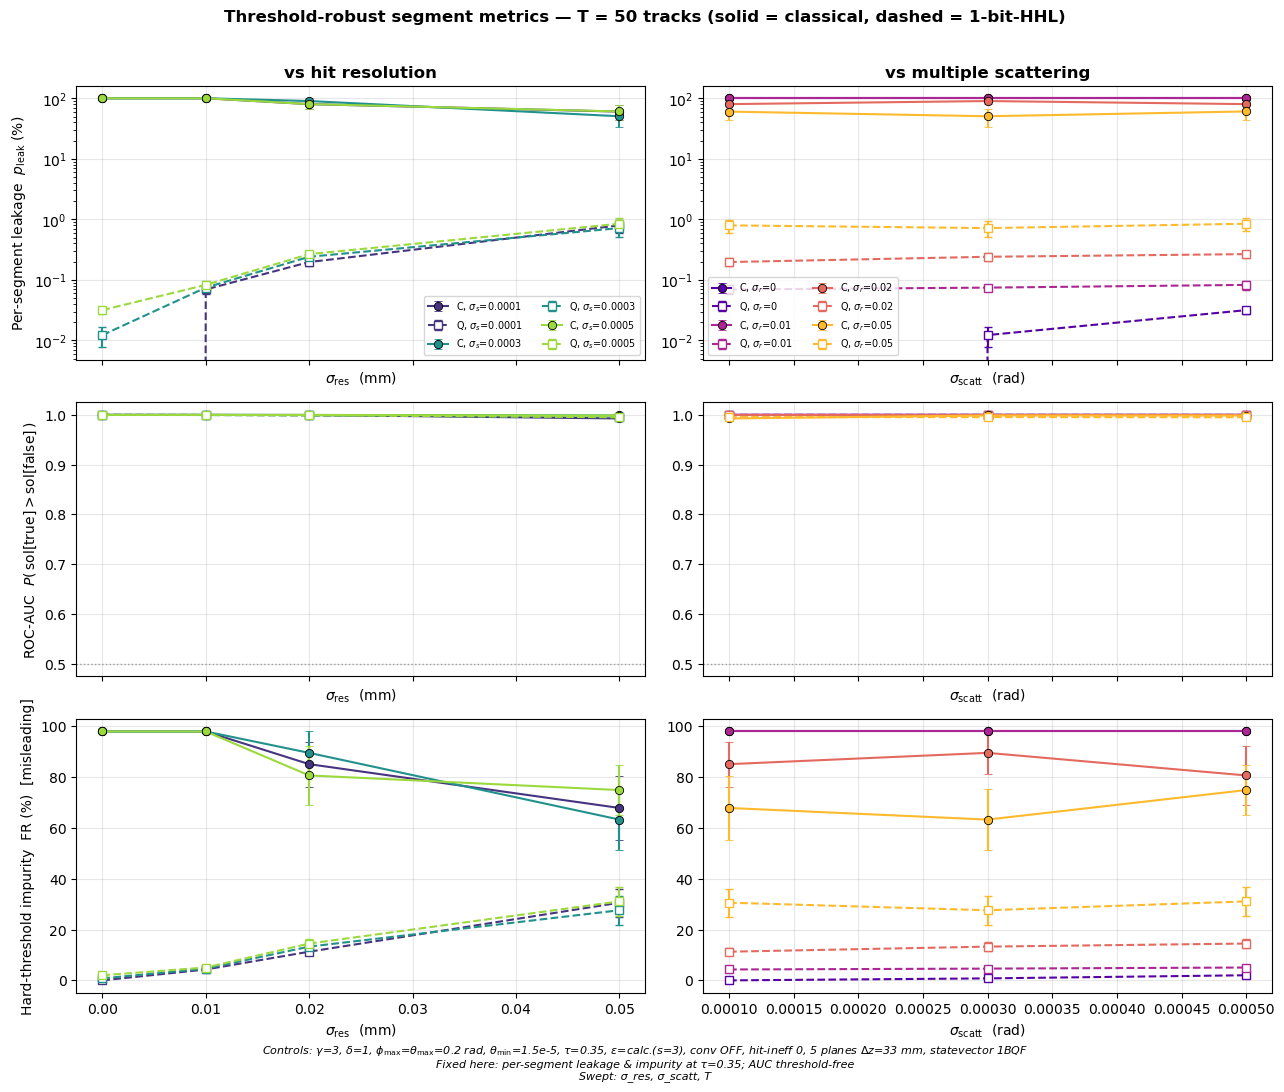

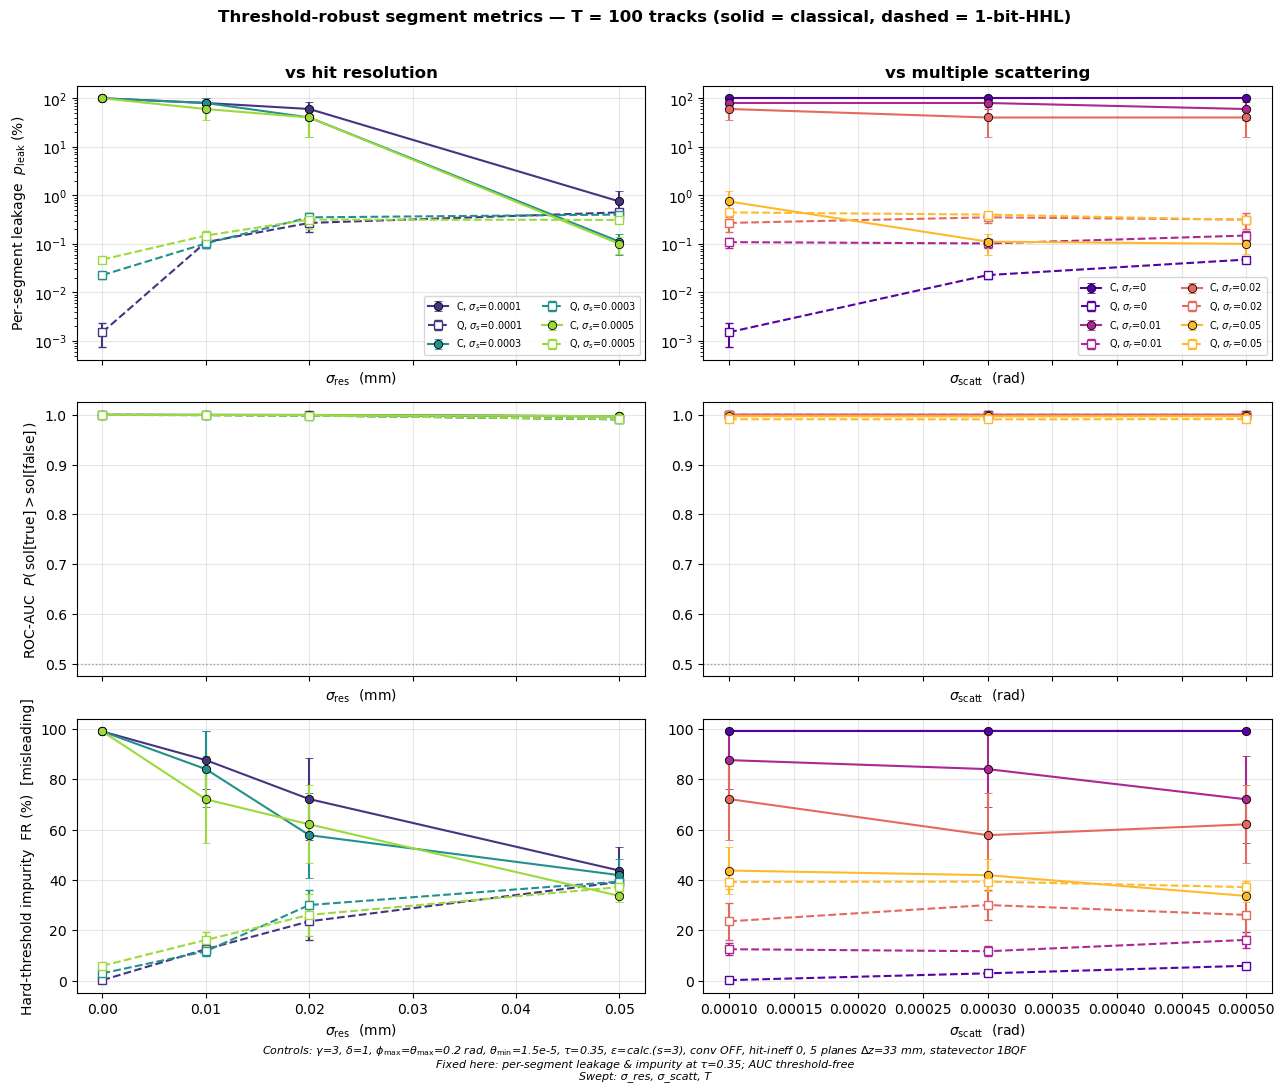

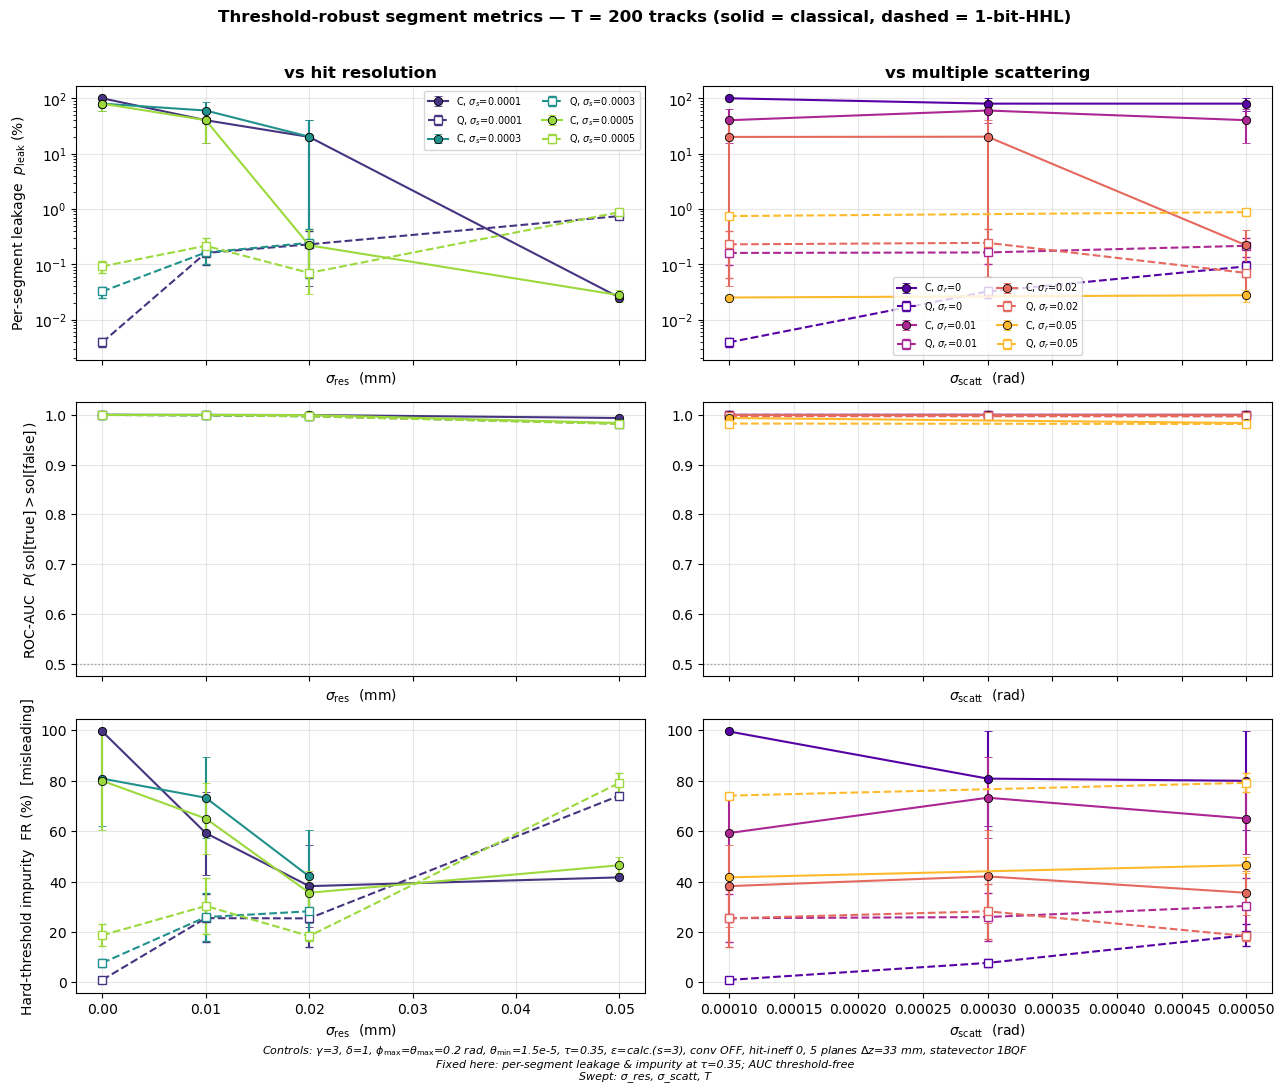

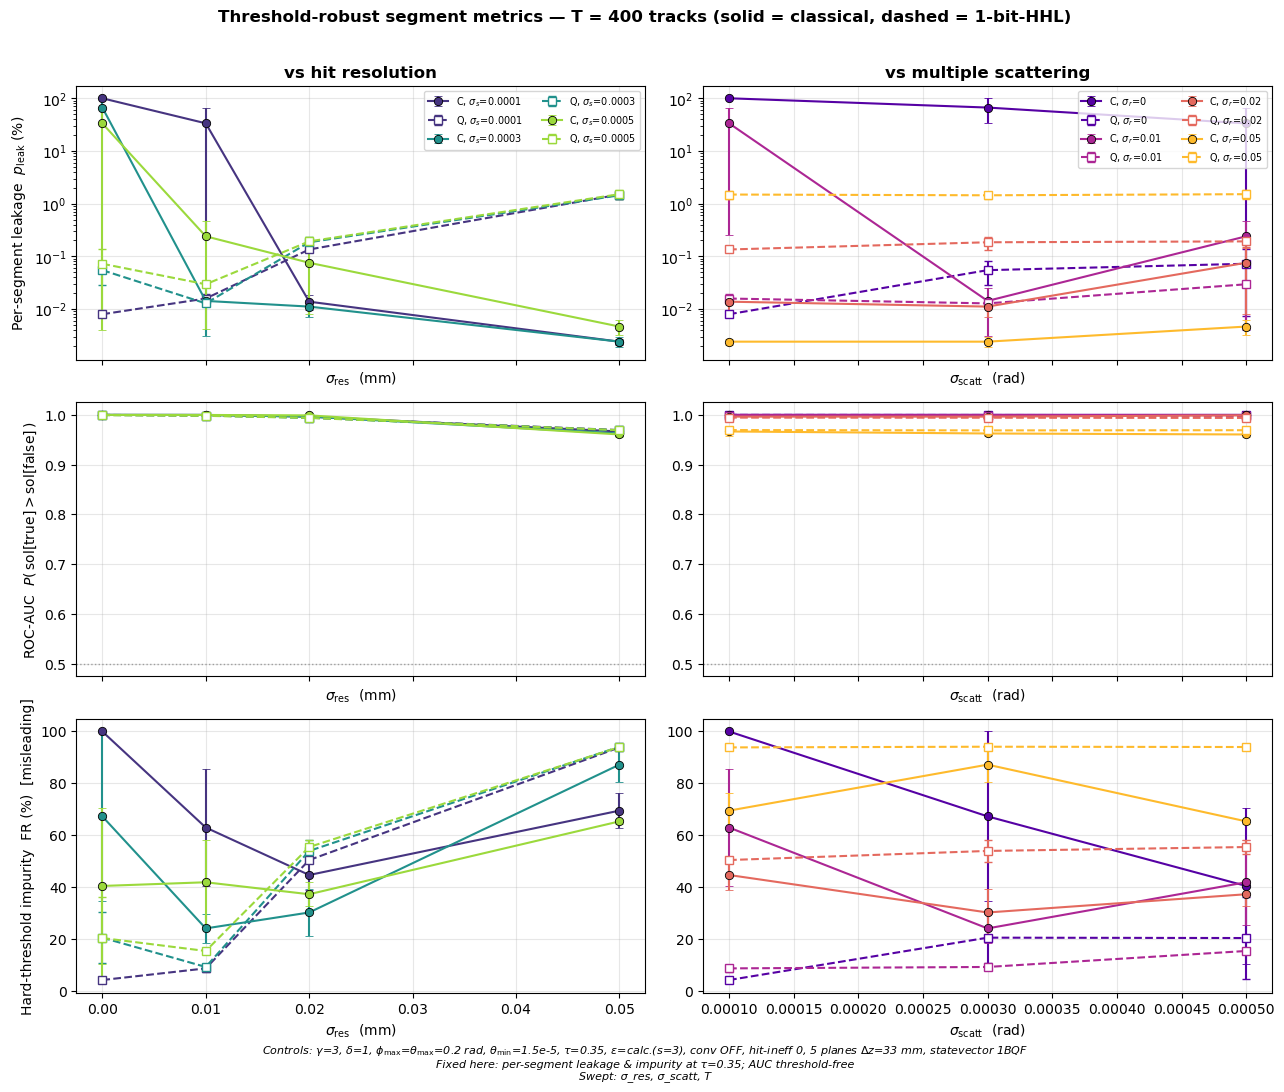

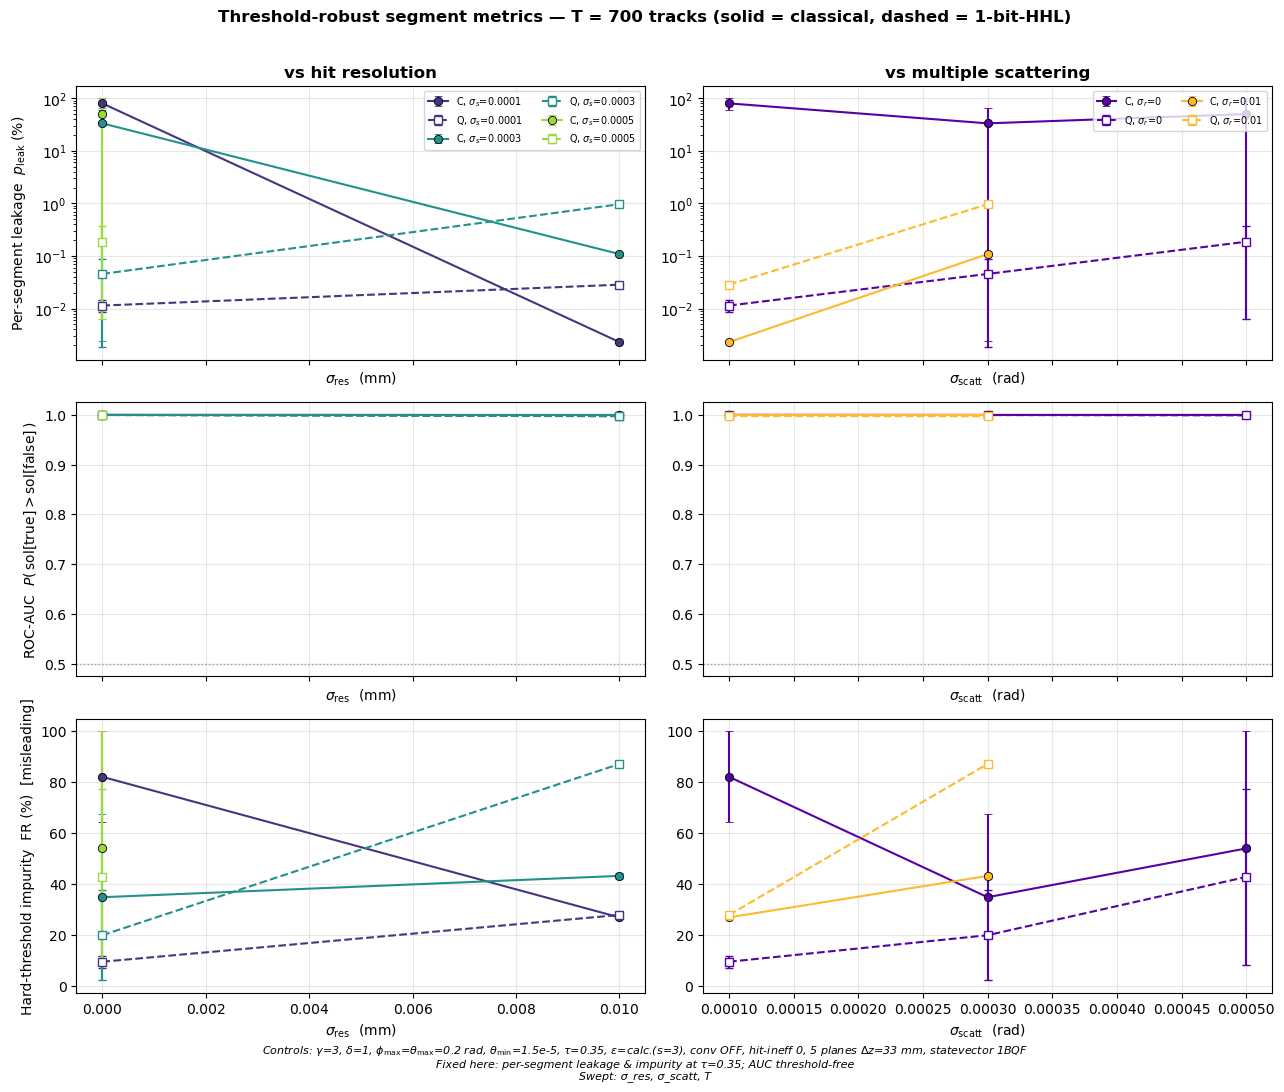

In [15]:
# ── plot the three metrics vs resolution and scattering, per T ─────────────
INF_FIGDIR = FIGDIR.parent / 'informative_metrics'
INF_FIGDIR.mkdir(parents=True, exist_ok=True)

_ROWS = [('pleak', 'Per-segment leakage  $p_{\\rm leak}$ (%)',          'log'),
         ('auc',   'ROC-AUC  $P(\\,$sol[true]$>$sol[false]$\\,)$',       'linear'),
         ('fr',    'Hard-threshold impurity  FR (%)  [misleading]',     'linear')]

def _plot_inf_T(T):
    sub = INF[INF['n_trk'] == T]
    if sub.empty:
        print(f"T={T}: no data — skipping"); return
    srs = sorted(sub['sigma_res'].unique())
    sss = sorted(sub['sigma_scatt'].unique())
    cmap_ss = plt.cm.viridis(np.linspace(0.15, 0.85, len(sss)))
    cmap_sr = plt.cm.plasma(np.linspace(0.15, 0.85, len(srs)))

    fig, axes = plt.subplots(len(_ROWS), 2, figsize=(13, 11), sharex='col')
    for ri, (key, ylab, yscale) in enumerate(_ROWS):
        axL, axR = axes[ri]
        # --- left: vs sigma_res, one trace per sigma_scatt ---
        for c, ss in zip(cmap_ss, sss):
            d = sub[sub['sigma_scatt'] == ss].sort_values('sigma_res')
            if d.empty: continue
            axL.errorbar(d['sigma_res'], d[f'{key}_C_mean'], yerr=d[f'{key}_C_sem'],
                         fmt='o-', color=c, capsize=3, mec='black', mew=0.6,
                         label=f'C, $\\sigma_s$={ss:g}')
            axL.errorbar(d['sigma_res'], d[f'{key}_Q_mean'], yerr=d[f'{key}_Q_sem'],
                         fmt='s--', color=c, capsize=3, mfc='white', mec=c,
                         label=f'Q, $\\sigma_s$={ss:g}')
        axL.set_ylabel(ylab); axL.set_yscale(yscale); axL.grid(alpha=0.3)
        axL.set_xlabel(r'$\sigma_{\rm res}$  (mm)')
        # --- right: vs sigma_scatt, one trace per sigma_res ---
        for c, sr in zip(cmap_sr, srs):
            d = sub[sub['sigma_res'] == sr].sort_values('sigma_scatt')
            if d.empty: continue
            axR.errorbar(d['sigma_scatt'], d[f'{key}_C_mean'], yerr=d[f'{key}_C_sem'],
                         fmt='o-', color=c, capsize=3, mec='black', mew=0.6,
                         label=f'C, $\\sigma_r$={sr:g}')
            axR.errorbar(d['sigma_scatt'], d[f'{key}_Q_mean'], yerr=d[f'{key}_Q_sem'],
                         fmt='s--', color=c, capsize=3, mfc='white', mec=c,
                         label=f'Q, $\\sigma_r$={sr:g}')
        axR.set_yscale(yscale); axR.grid(alpha=0.3)
        axR.set_xlabel(r'$\sigma_{\rm scatt}$  (rad)')
        if key == 'auc':
            for a in (axL, axR):
                a.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.7)
    axes[0, 0].set_title('vs hit resolution', fontweight='bold')
    axes[0, 1].set_title('vs multiple scattering', fontweight='bold')
    axes[0, 0].legend(fontsize=7, ncol=2, loc='best')
    axes[0, 1].legend(fontsize=7, ncol=2, loc='best')
    fig.suptitle(f'Threshold-robust segment metrics — T = {T} tracks '
                 '(solid = classical, dashed = 1-bit-HHL)', fontweight='bold')
    fig.text(0.5, 0.005, controls_caption(swept='σ_res, σ_scatt, T',
             extra='per-segment leakage & impurity at τ=0.35; AUC threshold-free'),
             ha='center', va='bottom', style='italic', fontsize=8, wrap=True)
    fig.tight_layout(rect=[0, 0.03, 1, 0.97])
    for ext in ('pdf', 'png'):
        fig.savefig(INF_FIGDIR / f'informative_metrics_T{T}.{ext}', bbox_inches='tight')
    plt.show()

for T in sorted(INF['n_trk'].unique()):
    _plot_inf_T(T)
